# Import

In [1]:
import matplotlib.patheffects as mpe
import matplotlib.pyplot as plt
import numpy as np
import pysam
import re
import pandas as pd
from matplotlib.ticker import FuncFormatter
plt.rcParams.update({'font.size': 20})
from collections import Counter
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import matplotlib.patches as patches
import matplotlib.ticker as ticker
import matplotlib

# Function

In [2]:
def plot(loc1,Xlabel,Ylabel,title,out):
    fig = plt.gcf()
    fig.set_size_inches(10,4)
    plt.rcParams.update({'font.size': 12})
    outline=mpe.withStroke(linewidth=8, foreground='black')

    # Extract keys as x labels and values as separate parts of the stack
    x_labels = list(loc1.keys())
    y1_values = [float(val[0]) for val in loc1.values()]  # First part of the stack (converted to float)
    y2_values = [float(val[1]) for val in loc1.values()]  # Second part of the stack (converted to int)

    # Set positions for x-axis
    x = np.arange(len(x_labels))

    # Create the stacked bar plot
    plt.bar(x, y1_values, label='methylated', color='blue',align='center',width=5)
    plt.bar(x, y2_values, bottom=y1_values, label='unmethylated', color='red',align='center',width=5)

    # Customize the plot
    tick_positions = np.arange(0, len(x_labels), 1000)  # Show ticks every 100 positions
    tick_labels = [f"{int(x_labels[i]):,}" for i in tick_positions]

    plt.xticks(tick_positions, tick_labels, rotation=45, fontsize=12)  # Rotate x labels for better visibility
    plt.xlabel(Xlabel, fontsize=12)
    plt.ylabel(Ylabel, fontsize=12)
    plt.title(title, fontsize=12)
    plt.legend(bbox_to_anchor=(0, -0.2), loc='upper left')
    plt.margins(0)
    

    # Add a border around the plot
    plt.gca().spines['top'].set_linewidth(1.5)
    plt.gca().spines['right'].set_linewidth(1.5)
    plt.gca().spines['bottom'].set_linewidth(1.5)
    plt.gca().spines['left'].set_linewidth(1.5)
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42
    plt.savefig("/media/data_01/vapatter/PROJECTS/15-LARS/PDF/"+out+"_methylation.pdf", format="pdf", bbox_inches="tight")

    # Show plot
    plt.tight_layout()
    plt.show()

In [45]:
def plotDepthIntron(loc1,inFile,file, title):
    depth_file = "/media/data_01/vapatter/PROJECTS/15-LARS/"+inFile  # Replace with your samtools depth output file
    positions, depths = [], []

    with open(depth_file) as f:
        for line in f:
            chrom, pos, depth = line.strip().split("\t")
            positions.append(int(pos))
            depths.append(int(depth))

    fig = plt.gcf()
    fig.set_size_inches(10,4)
    plt.rcParams.update({'font.size': 12})
    outline=mpe.withStroke(linewidth=8, foreground='black')


    # Extract keys as x labels and values as separate parts of the stack
    x_labels = list(loc1.keys())
    y1_values = [float(val[0]) for val in loc1.values()]  # First part of the stack (converted to float)

    # Set positions for x-axis
    x = np.arange(len(x_labels))
    # Create the stacked bar plot
    plt.bar(x, depths, color='brown',width=1.0, alpha=1)

    # Customize the plot
    tick_positions = np.arange(0, len(x_labels), 1000)  # Show ticks every 100 positions
    tick_labels = [f"{int(x_labels[i]):,}" for i in tick_positions]

    plt.xticks(tick_positions, tick_labels, rotation=45, fontsize=12)  # Rotate x labels for better visibility
    plt.xlabel("Positions", fontsize=12)
    plt.ylabel("Coverage", fontsize=12)
    plt.title(title, fontsize=12)
    #plt.legend(bbox_to_anchor=(0, -0.2), loc='upper left')
    plt.margins(0)
    

    # Add a border around the plot
    plt.gca().spines['top'].set_linewidth(1.5)
    plt.gca().spines['right'].set_linewidth(1.5)
    plt.gca().spines['bottom'].set_linewidth(1.5)
    plt.gca().spines['left'].set_linewidth(1.5)
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42
    print(file)
    plt.savefig("/media/data_01/vapatter/PROJECTS/15-LARS/PDF/"+title+".pdf", format="pdf", bbox_inches="tight")

    # Show plot
    plt.tight_layout()
    plt.show()

In [4]:
def Intron6t8meth(inFile,out):
    file = open("/media/data_01/shared/GENOMES/homo_sapiens/T2T-CHM13v2.0/genome/loc1.fa","r")

    seqLoc2 = {}

    count = 1175534

    for line in file:
        a = list(line)
        for i in a:
            count +=1
            seqLoc2[count]=[0,0]
    file.close()   

    file = open("/media/data_01/vapatter/PROJECTS/15-LARS/"+inFile,"r")
    for line in file:
        cols = line.split("\t")
        if cols[0]=="NC_060929.1" and int(cols[1])>=1175535 and int(cols[1])<=1181032 and cols[3]=="m":
            for k,v in seqLoc2.items():
                if int(cols[1])==k:
                    seqLoc2[k]=[cols[10],100-float(cols[10])]
    file.close()  
    print(str(inFile))
    plot(seqLoc2,"Positions","Percentage", "Percentage of CpG Methylation in Intron 6 to 8", out)

In [44]:
def plotDepthTAPAS(loc1,inFile,file,title):
    depth_file = "/media/data_01/vapatter/PROJECTS/15-LARS/"+inFile  # Replace with your samtools depth output file
    positions, depths = [], []

    with open(depth_file) as f:
        for line in f:
            chrom, pos, depth = line.strip().split("\t")
            positions.append(int(pos))
            depths.append(int(depth))

    fig = plt.gcf()
    fig.set_size_inches(10,4)
    plt.rcParams.update({'font.size': 12})
    outline=mpe.withStroke(linewidth=8, foreground='black')


    # Extract keys as x labels and values as separate parts of the stack
    x_labels = list(loc1.keys())
    y1_values = [float(val[0]) for val in loc1.values()]  # First part of the stack (converted to float)

    # Set positions for x-axis
    x = np.arange(len(x_labels))
    # Create the stacked bar plot
    plt.bar(x, depths, color='brown',width=1.0, alpha=1)

    # Customize the plot
    tick_positions = np.arange(0, len(x_labels), 1000)  # Show ticks every 100 positions
    tick_labels = [f"{int(x_labels[i]):,}" for i in tick_positions]

    plt.xticks(tick_positions, tick_labels, rotation=45, fontsize=12)  # Rotate x labels for better visibility
    plt.xlabel("Positions", fontsize=12)
    plt.ylabel("Coverage", fontsize=12)
    plt.title(title, fontsize=12)
    #plt.legend(bbox_to_anchor=(0, -0.2), loc='upper left')
    plt.margins(0)
    

    # Add a border around the plot
    plt.gca().spines['top'].set_linewidth(1.5)
    plt.gca().spines['right'].set_linewidth(1.5)
    plt.gca().spines['bottom'].set_linewidth(1.5)
    plt.gca().spines['left'].set_linewidth(1.5)
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42
    print(file)
    plt.savefig("/media/data_01/vapatter/PROJECTS/15-LARS/PDF/"+title+".pdf", format="pdf", bbox_inches="tight")

    # Show plot
    plt.tight_layout()
    plt.show()

In [6]:
 def TAPASmeth(inFile,out):
    file = open("/media/data_01/shared/GENOMES/homo_sapiens/T2T-CHM13v2.0/genome/loc2.fa","r")

    seqLoc2 = {}

    count = 1196005

    for line in file:
        a = list(line)
        for i in a:
            count +=1
            seqLoc2[count]=[0,0]
    file.close()   

    file = open("/media/data_01/vapatter/PROJECTS/15-LARS/"+inFile,"r")
    for line in file:
        cols = line.split("\t")
        if cols[0]=="NC_060929.1" and int(cols[1])>=1196006 and int(cols[1])<=1205278 and cols[3]=="m":
            for k,v in seqLoc2.items():
                if int(cols[1])==k:
                    seqLoc2[k]=[cols[10],100-float(cols[10])]
    file.close()  
    print(str(inFile))
    plot(seqLoc2,"Positions","Percentage", "Percentage CpG Methylation Across hTAPAS to Intron 2", out)

In [7]:
def plotCov(loc1,Xlabel,Ylabel,title,out):
    fig = plt.gcf()
    fig.set_size_inches(10,4)
    plt.rcParams.update({'font.size': 12})
    outline=mpe.withStroke(linewidth=8, foreground='black')

    # Extract keys as x labels and values as separate parts of the stack
    x_labels = list(loc1.keys())
    y1_values = [float(val[0]) for val in loc1.values()]  # First part of the stack (converted to float)

    # Set positions for x-axis
    x = np.arange(len(x_labels))

    # Create the stacked bar plot
    plt.bar(x, y1_values, label='coverage', color='brown',align='center',width=5)

    # Customize the plot
    tick_positions = np.arange(0, len(x_labels), 1000)  # Show ticks every 100 positions
    tick_labels = [f"{int(x_labels[i]):,}" for i in tick_positions]

    plt.xticks(tick_positions, tick_labels, rotation=45, fontsize=12)  # Rotate x labels for better visibility
    plt.xlabel(Xlabel, fontsize=12)
    plt.ylabel(Ylabel, fontsize=12)
    plt.title(title, fontsize=12)
    plt.legend(bbox_to_anchor=(0, -0.2), loc='upper left')
    plt.margins(0)
    

    # Add a border around the plot
    plt.gca().spines['top'].set_linewidth(1.5)
    plt.gca().spines['right'].set_linewidth(1.5)
    plt.gca().spines['bottom'].set_linewidth(1.5)
    plt.gca().spines['left'].set_linewidth(1.5)
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42

    plt.savefig("/media/data_01/vapatter/PROJECTS/15-LARS/PDF/"+out+"_coverage.pdf", format="pdf", bbox_inches="tight")

    # Show plot
    plt.tight_layout()
    plt.show()

In [8]:

# Function to parse SAM file and filter primary alignments
def parse_sam(sam_file):
    primary_alignments = []
    chromosomes = set()  # Set to store unique chromosome names
    
    with open(sam_file, 'r') as file:
        for line in file:
            if line.startswith('@'):
                continue  # Skip header lines
            fields = line.strip().split('\t')
            flag = int(fields[1])
            if (flag & 0x100) == 0:  # Primary alignment
                chrom = fields[2]
                pos = int(fields[3])
                primary_alignments.append((chrom, pos))
                chromosomes.add(chrom)  # Add chromosome to set
    
    return pd.DataFrame(primary_alignments, columns=['chr', 'position']), chromosomes

# Load SAM data and get unique chromosomes
primary_alignments, chromosomes = parse_sam(sam_file)

# Chromosome order for plotting (adapted based on the SAM file)
chromosomes = sorted(chromosomes)  # Sort chromosomes alphabetically

# Set bin size for density calculation (1 Mb bins)
bin_size = 1_000_000

# Function to calculate read density in bins
def calculate_read_density(primary_alignments, bin_size, chromosomes):
    density_data = []
    for chrom in chromosomes:
        chrom_reads = primary_alignments[primary_alignments['chr'] == chrom]
        max_pos = chrom_reads['position'].max() if not chrom_reads.empty else 0
        bins = np.arange(0, max_pos + bin_size, bin_size)
        bin_counts, _ = np.histogram(chrom_reads['position'], bins=bins)
        density_data.extend([(chrom, start, start + bin_size, count) for start, count in zip(bins[:-1], bin_counts)])
    return pd.DataFrame(density_data, columns=['chr', 'start', 'end', 'count'])

# Calculate read density
read_density = calculate_read_density(primary_alignments, bin_size, chromosomes)

# Plotting function for karyotype with density
def plot_karyotype_with_density(read_density, chromosomes):
    fig, ax = plt.subplots(figsize=(12, 8))
    y_position = 0

    # Iterate over each chromosome to plot read density
    for chrom in chromosomes:
        chrom_density = read_density[read_density['chr'] == chrom]
        
        max_pos = chrom_density['end'].max() if not chrom_density.empty else 0
        chrom_width = 0.6
        
        # Overlay density as a heatmap along the chromosome
        max_density = read_density['count'].max()  # Normalize based on maximum density
        for _, row in chrom_density.iterrows():
            density = row['count']
            intensity = density / max_density  # Normalize density to [0, 1]
            color = plt.cm.Reds(intensity)  # Use Reds colormap for heatmap effect
            rect = patches.Rectangle((y_position - chrom_width / 2, row['start']), chrom_width, row['end'] - row['start'],
                                     linewidth=0, edgecolor='none', facecolor=color)
            ax.add_patch(rect)

        # Label the chromosome
        ax.text(y_position, max_pos + 5e6, chrom, ha='center', va='bottom', fontsize=10)
        y_position += 1

    # Set the limits and labels
    ax.set_ylim(0, max(read_density['end']))
    ax.set_xlim(-1, y_position)
    ax.set_xlabel("Chromosomes")
    ax.set_ylabel("Position on Chromosome")
    ax.set_title("Read Density on Chromosomes")

    plt.colorbar(plt.cm.ScalarMappable(cmap='Reds'), ax=ax, orientation='horizontal', label='Read Density')
    plt.show()


NameError: name 'sam_file' is not defined

# Off Targets 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
sam_file = "/media/data_01/vapatter/PROJECTS/15-LARS/144_LE_hTERT_CRISPR_VA13_Aza/T2T/HEK_Aza_cutsitetest_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.sam"

# Function to parse SAM file and filter primary alignments
def parse_sam(sam_file):
    primary_alignments = []
    chromosomes = set()  # Set to store unique chromosome names
    
    with open(sam_file, 'r') as file:
        for line in file:
            if line.startswith('@'):
                continue  # Skip header lines
            fields = line.strip().split('\t')
            flag = int(fields[1])
            if (flag & 0x100) == 0:  # Primary alignment
                chrom = fields[2]
                pos = int(fields[3])
                primary_alignments.append((chrom, pos))
                chromosomes.add(chrom)  # Add chromosome to set
    
    return pd.DataFrame(primary_alignments, columns=['chr', 'position']), chromosomes

# Load SAM data and get unique chromosomes
primary_alignments, chromosomes = parse_sam(sam_file)

# Chromosome order for plotting (adapted based on the SAM file)
chromosomes = sorted(chromosomes)  # Sort chromosomes alphabetically

# Set bin size for density calculation (1 Mb bins)
bin_size = 1_000_000

# Function to calculate read density in bins
def calculate_read_density(primary_alignments, bin_size, chromosomes):
    density_data = []
    for chrom in chromosomes:
        chrom_reads = primary_alignments[primary_alignments['chr'] == chrom]
        max_pos = chrom_reads['position'].max() if not chrom_reads.empty else 0
        bins = np.arange(0, max_pos + bin_size, bin_size)
        bin_counts, _ = np.histogram(chrom_reads['position'], bins=bins)
        density_data.extend([(chrom, start, start + bin_size, count) for start, count in zip(bins[:-1], bin_counts)])
    return pd.DataFrame(density_data, columns=['chr', 'start', 'end', 'count'])

# Calculate read density
read_density = calculate_read_density(primary_alignments, bin_size, chromosomes)

# Plotting function for karyotype with density
def plot_karyotype_with_density(read_density, chromosomes):
    fig, ax = plt.subplots(figsize=(12, 8))
    y_position = 0

    # Iterate over each chromosome to plot read density
    for chrom in chromosomes:
        chrom_density = read_density[read_density['chr'] == chrom]
        
        max_pos = chrom_density['end'].max() if not chrom_density.empty else 0
        chrom_width = 0.6
        
        # Overlay density as a heatmap along the chromosome
        max_density = read_density['count'].max()  # Normalize based on maximum density
        for _, row in chrom_density.iterrows():
            density = row['count']
            intensity = density / max_density  # Normalize density to [0, 1]
            color = plt.cm.Reds(intensity)  # Use Reds colormap for heatmap effect
            rect = patches.Rectangle((y_position - chrom_width / 2, row['start']), chrom_width, row['end'] - row['start'],
                                     linewidth=0, edgecolor='none', facecolor=color)
            ax.add_patch(rect)

        # Label the chromosome
        ax.text(y_position, max_pos + 5e6, chrom, ha='center', va='bottom', fontsize=10)
        y_position += 1

    # Set the limits and labels
    ax.set_ylim(0, max(read_density['end']))
    ax.set_xlim(-1, y_position)
    ax.set_xlabel("Chromosomes")
    ax.set_ylabel("Position on Chromosome")
    ax.set_title("Read Density on Chromosomes")

    plt.colorbar(plt.cm.ScalarMappable(cmap='Reds'), ax=ax, orientation='horizontal', label='Read Density')
    plt.show()

# Plot the karyotype with read density
plot_karyotype_with_density(read_density, chromosomes)

In [ ]:
# File paths
sam_file = "/media/data_01/vapatter/PROJECTS/15-LARS/144_LE_hTERT_CRISPR_VA13_Aza/T2T/DORADO_DEMUX/6625ff67fb7d802182a83888398d8e73dbfd09d5_EXP-NBD114_barcode13.bam.aligned.bam.sorted.bam.sam"
# Load SAM data and get unique chromosomes
primary_alignments, chromosomes = parse_sam(sam_file)

# Chromosome order for plotting (adapted based on the SAM file)
chromosomes = sorted(chromosomes)  # Sort chromosomes alphabetically

# Set bin size for density calculation (1 Mb bins)
bin_size = 1_000_000
# Calculate read density
read_density = calculate_read_density(primary_alignments, bin_size, chromosomes)
# Plot the karyotype with read density
plot_karyotype_with_density(read_density, chromosomes)

In [ ]:
# File paths
sam_file = "/media/data_01/vapatter/PROJECTS/15-LARS/144_LE_hTERT_CRISPR_VA13_Aza/T2T/DORADO_DEMUX/6625ff67fb7d802182a83888398d8e73dbfd09d5_EXP-NBD114_barcode22.bam.aligned.bam.sorted.bam.sam"
# Load SAM data and get unique chromosomes
primary_alignments, chromosomes = parse_sam(sam_file)

# Chromosome order for plotting (adapted based on the SAM file)
chromosomes = sorted(chromosomes)  # Sort chromosomes alphabetically

# Set bin size for density calculation (1 Mb bins)
bin_size = 1_000_000
# Calculate read density
read_density = calculate_read_density(primary_alignments, bin_size, chromosomes)
# Plot the karyotype with read density
plot_karyotype_with_density(read_density, chromosomes)

In [ ]:
# File paths
sam_file = "/media/data_01/vapatter/PROJECTS/15-LARS/144_LE_hTERT_CRISPR_VA13_Aza/T2T/DORADO_DEMUX/6625ff67fb7d802182a83888398d8e73dbfd09d5_EXP-NBD114_barcode24.bam.aligned.bam.sorted.bam.sam"
# Load SAM data and get unique chromosomes
primary_alignments, chromosomes = parse_sam(sam_file)

# Chromosome order for plotting (adapted based on the SAM file)
chromosomes = sorted(chromosomes)  # Sort chromosomes alphabetically

# Set bin size for density calculation (1 Mb bins)
bin_size = 1_000_000
# Calculate read density
read_density = calculate_read_density(primary_alignments, bin_size, chromosomes)
# Plot the karyotype with read density
plot_karyotype_with_density(read_density, chromosomes)

# Intron 6 to 8

## Coverage

In [9]:
%%bash
cd /media/data_01/vapatter/PROJECTS/15-LARS/144_LE_hTERT_CRISPR_VA13_Aza/T2T/
for f in *sorted.bam; do 
ls $f
samtools depth -r NC_060929.1:1175535-1181032 $f | awk '
{
    sum += $3;                          # Sum of depths
    sumsq += $3 * $3;                   # Sum of squares of depths
    count++;                             # Count of positions
}
END {
    if (count > 0) {
        avg = sum / count;               # Average depth
        variance = (sumsq / count) - (avg * avg);  # Variance
        stddev = (variance > 0) ? sqrt(variance) : 0;  # Standard deviation
        print "Average depth:", avg;
        print "Standard deviation:", stddev;
    } else {
        print "No data";
    }
}'
samtools view -F 4 $f NC_060929.1:1175535-1181032 | wc -l
samtools view -F 4 -F 256 $f NC_060929.1:1175535-1181032 | wc -l; done

VA13_Aza_barcodetest_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam
Average depth: 34.6131
Standard deviation: 4.50322
144
132


In [19]:
%%bash
cd /media/data_01/vapatter/PROJECTS/15-LARS/144_LE_hTERT_CRISPR_VA13_Aza/T2T/DORADO_DEMUX
for f in *sorted.bam; do 
ls $f
samtools depth -r NC_060929.1:1175535-1181032 $f | awk '
{
    sum += $3;                          # Sum of depths
    sumsq += $3 * $3;                   # Sum of squares of depths
    count++;                             # Count of positions
}
END {
    if (count > 0) {
        avg = sum / count;               # Average depth
        variance = (sumsq / count) - (avg * avg);  # Variance
        stddev = (variance > 0) ? sqrt(variance) : 0;  # Standard deviation
        print "Average depth:", avg;
        print "Standard deviation:", stddev;
    } else {
        print "No data";
    }
}'
samtools view -F 4 $f NC_060929.1:1175535-1181032 | wc -l
samtools view -F 4 -F 256 $f NC_060929.1:1175535-1181032 | wc -l; done

b46be69c02e8f52145e7b3019738042afe7c7fff_EXP-NBD104_barcode06.bam.aligned.bam.sorted.bam
Average depth: 9.73772
Standard deviation: 0.76669
15
13
b46be69c02e8f52145e7b3019738042afe7c7fff_EXP-NBD104_barcode07.bam.aligned.bam.sorted.bam
Average depth: 2.79192
Standard deviation: 0.736953
4
4
b46be69c02e8f52145e7b3019738042afe7c7fff_EXP-NBD104_barcode12.bam.aligned.bam.sorted.bam
Average depth: 1.99291
Standard deviation: 0.103348
3
3
b46be69c02e8f52145e7b3019738042afe7c7fff_EXP-NBD114_barcode22.bam.aligned.bam.sorted.bam
Average depth: 18.0018
Standard deviation: 4.46945
115
105
b46be69c02e8f52145e7b3019738042afe7c7fff_unclassified.bam.aligned.bam.sorted.bam
Average depth: 20.0906
Standard deviation: 4.71353
122
112


b46be69c02e8f52145e7b3019738042afe7c7fff_EXP-NBD104_barcode06.bam.aligned.bam.sorted.bam.intron_coverage.txt


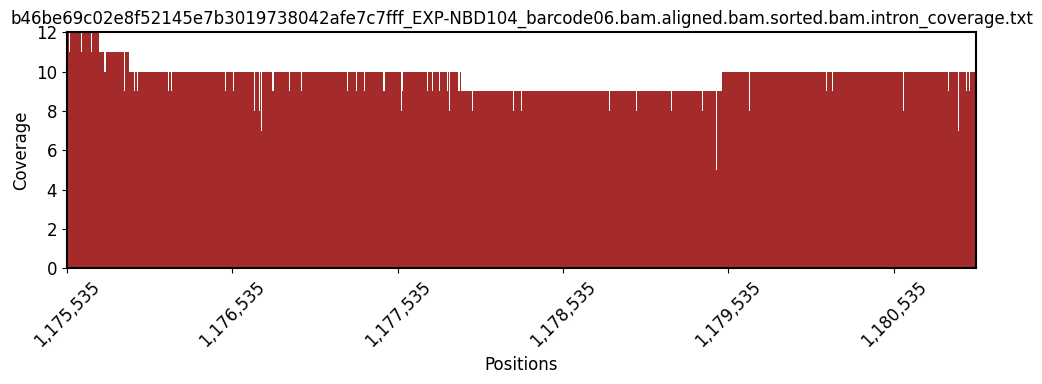

b46be69c02e8f52145e7b3019738042afe7c7fff_EXP-NBD104_barcode07.bam.aligned.bam.sorted.bam.intron_coverage.txt


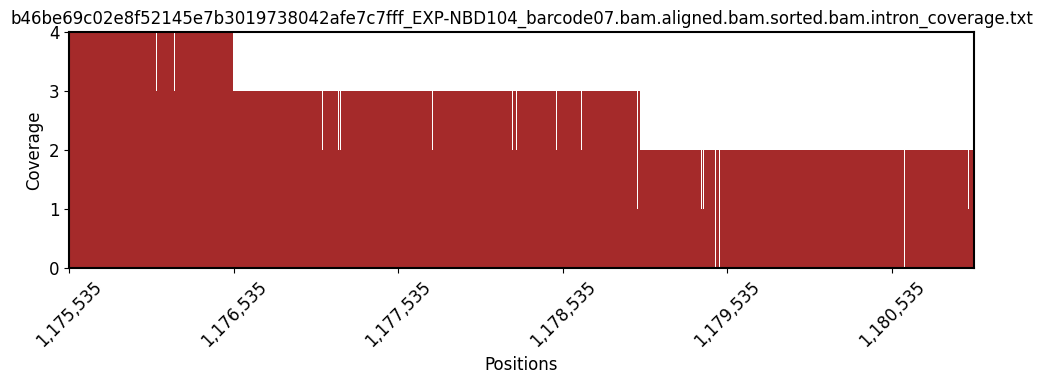

b46be69c02e8f52145e7b3019738042afe7c7fff_EXP-NBD104_barcode12.bam.aligned.bam.sorted.bam.intron_coverage.txt


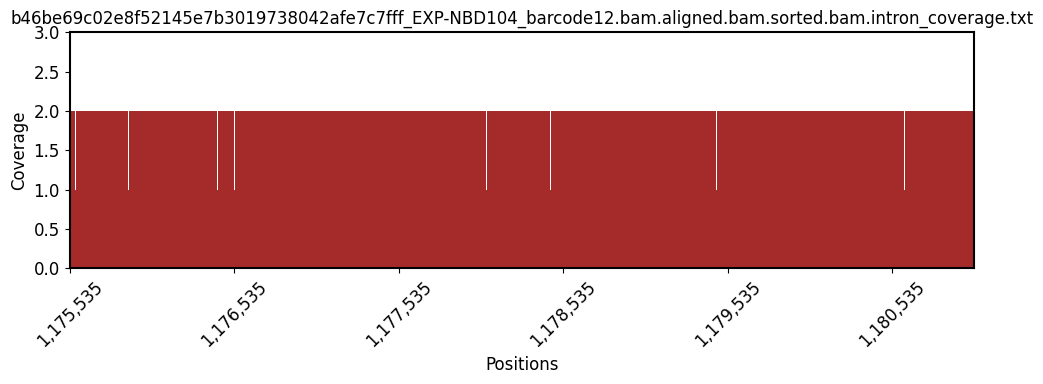

b46be69c02e8f52145e7b3019738042afe7c7fff_EXP-NBD114_barcode22.bam.aligned.bam.sorted.bam.intron_coverage.txt


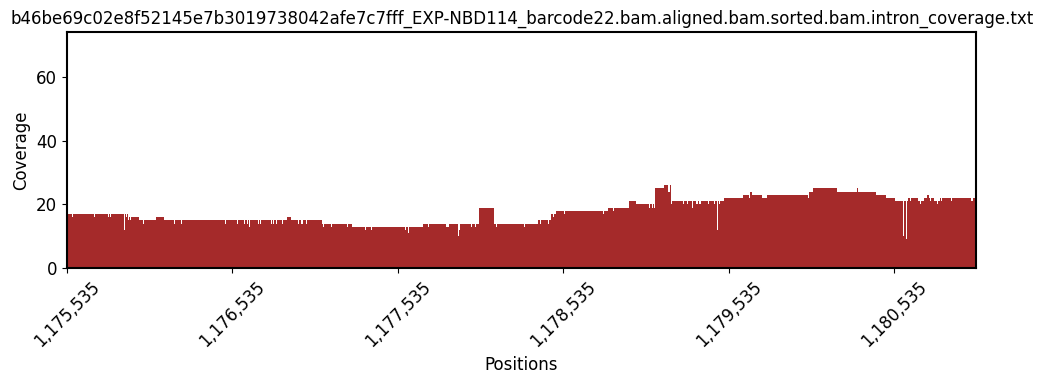

In [62]:
file = open("/media/data_01/shared/GENOMES/homo_sapiens/T2T-CHM13v2.0/genome/loc1.fa","r")

seqLoc2 = {}

count = 1175534

for line in file:
    a = list(line)
    for i in a:
        count +=1
        seqLoc2[count]=[count]
file.close()
files = pd.read_csv("/media/data_01/vapatter/PROJECTS/15-LARS/144_LE_hTERT_CRISPR_VA13_Aza/T2T/DORADO_DEMUX/coveragesINTRON.txt", header = None)
files = list(files[0])
for f in files:
    plotDepthIntron(seqLoc2,"144_LE_hTERT_CRISPR_VA13_Aza/T2T/DORADO_DEMUX/"+f,f,f)

HEK_K_24.bam.sorted.bam.aligned.bam.sorted.bam.intron.txt


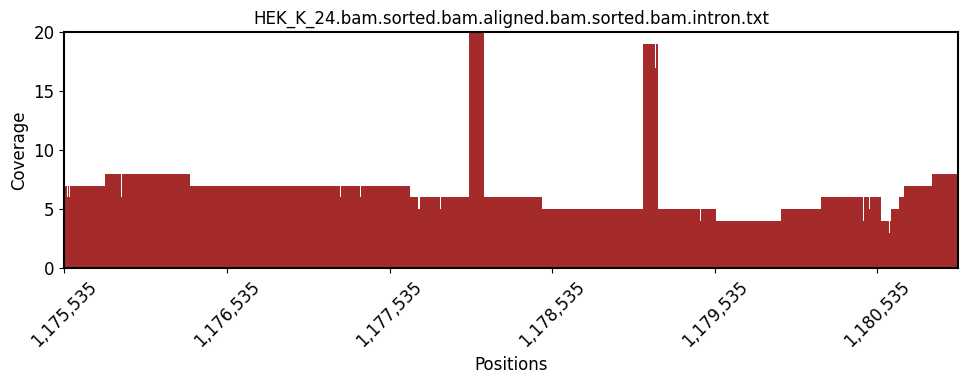

HEK_S_24.bam.sorted.bam.aligned.bam.sorted.bam.intron.txt


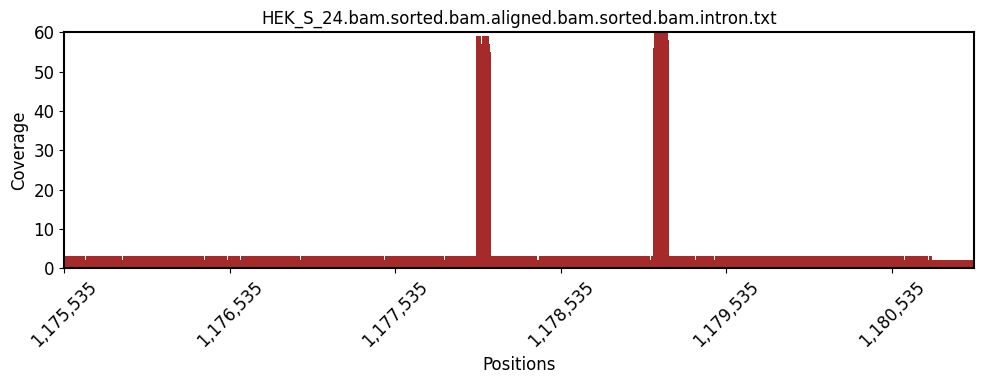

HEK_T2_24.bam.sorted.bam.aligned.bam.sorted.bam.intron.txt


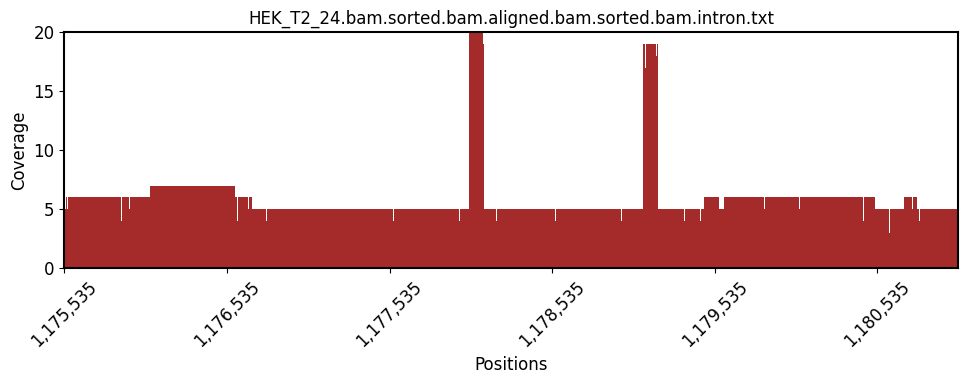

HEK_TM_24.bam.sorted.bam.aligned.bam.sorted.bam.intron.txt


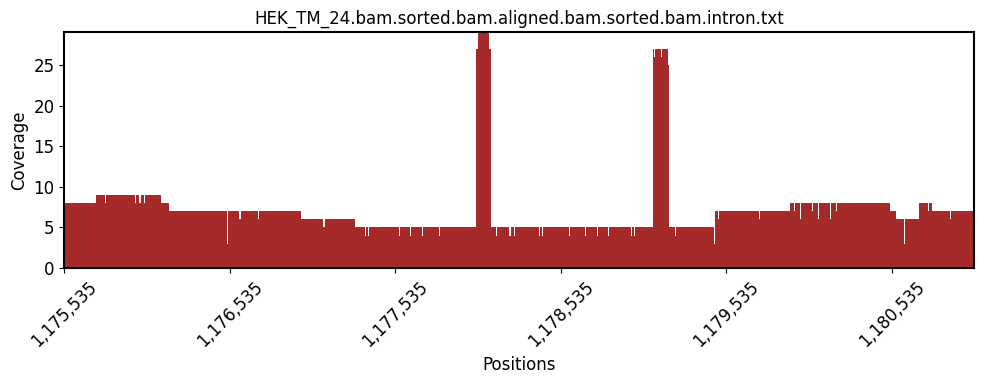

HEK_T_24.bam.sorted.bam.aligned.bam.sorted.bam.intron.txt


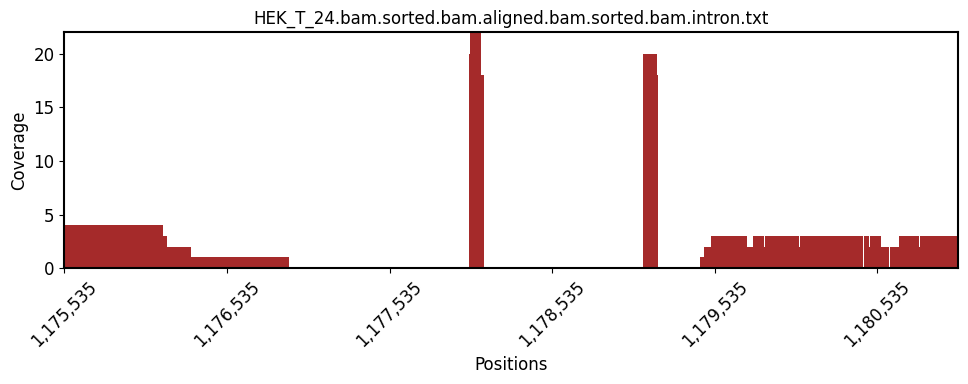

In [61]:
file = open("/media/data_01/shared/GENOMES/homo_sapiens/T2T-CHM13v2.0/genome/loc1.fa","r")

seqLoc2 = {}

count = 1175534

for line in file:
    a = list(line)
    for i in a:
        count +=1
        seqLoc2[count]=[count]
file.close()
files = pd.read_csv("/media/data_01/vapatter/PROJECTS/15-LARS/MERGED_HEK_24h_hTAPAS/coverage_intron.txt", header = None)
files = list(files[0])
for f in files:
    plotDepthIntron(seqLoc2,"MERGED_HEK_24h_hTAPAS/"+f,f,f)

VA13_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.intron.txt


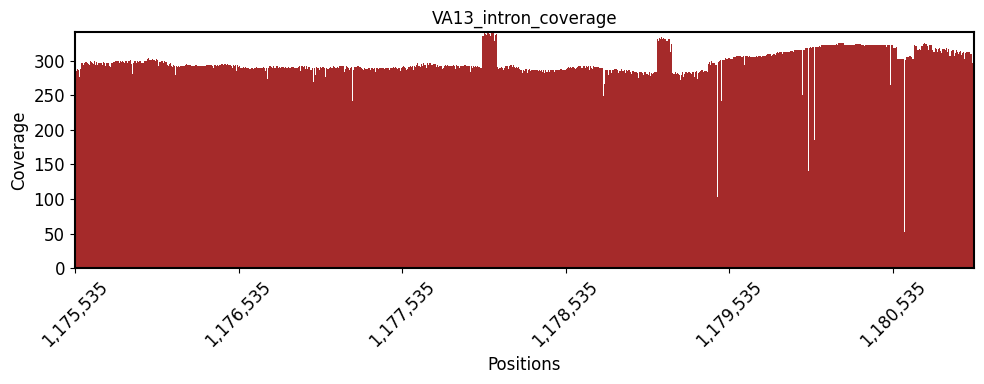

In [46]:
file = open("/media/data_01/shared/GENOMES/homo_sapiens/T2T-CHM13v2.0/genome/loc1.fa","r")

seqLoc2 = {}

count = 1175534

for line in file:
    a = list(line)
    for i in a:
        count +=1
        seqLoc2[count]=[count]
file.close()

plotDepthIntron(seqLoc2,"125_NDLE_hTERT_CRISPR_VA13/T2T/VA13_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.intron.txt",
                "VA13_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.intron.txt", "VA13_intron_coverage" )

barcode24_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.intron.txt


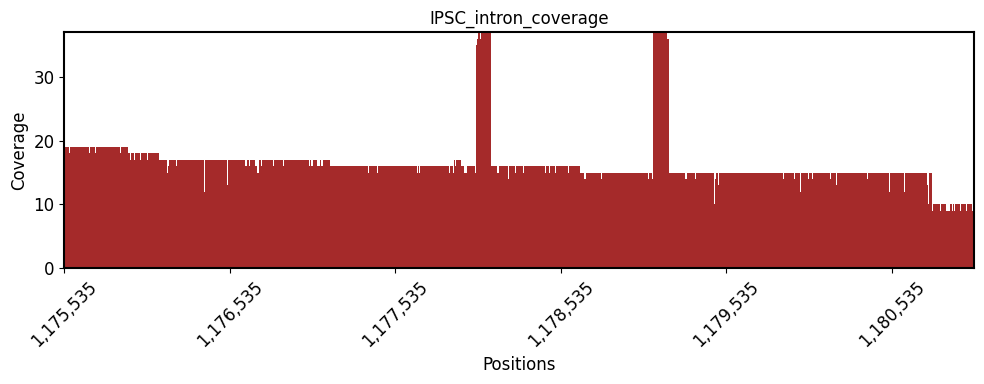

In [47]:
file = open("/media/data_01/shared/GENOMES/homo_sapiens/T2T-CHM13v2.0/genome/loc1.fa","r")

seqLoc2 = {}

count = 1175534

for line in file:
    a = list(line)
    for i in a:
        count +=1
        seqLoc2[count]=[count]
file.close()
file = "barcode24_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.intron.txt"
plotDepthIntron(seqLoc2,"126_LE_hTERT_CRISPR_HEK_IPS/T2T/"+file,file,
                "IPSC_intron_coverage")

barcode22_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.intron.txt


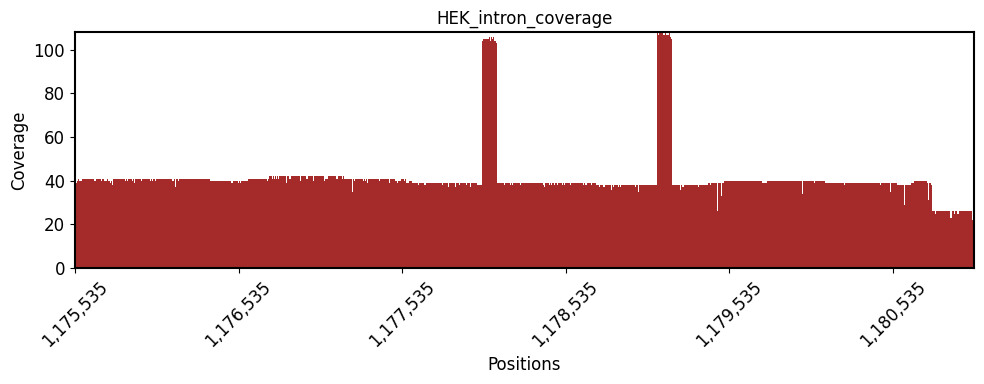

In [48]:
file = open("/media/data_01/shared/GENOMES/homo_sapiens/T2T-CHM13v2.0/genome/loc1.fa","r")

seqLoc2 = {}

count = 1175534

for line in file:
    a = list(line)
    for i in a:
        count +=1
        seqLoc2[count]=[count]
file.close()
file = "barcode22_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.intron.txt"
plotDepthIntron(seqLoc2,"126_LE_hTERT_CRISPR_HEK_IPS/T2T/"+file,file,
                "HEK_intron_coverage")

HEK_Aza_cutsitetest_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.intron.txt


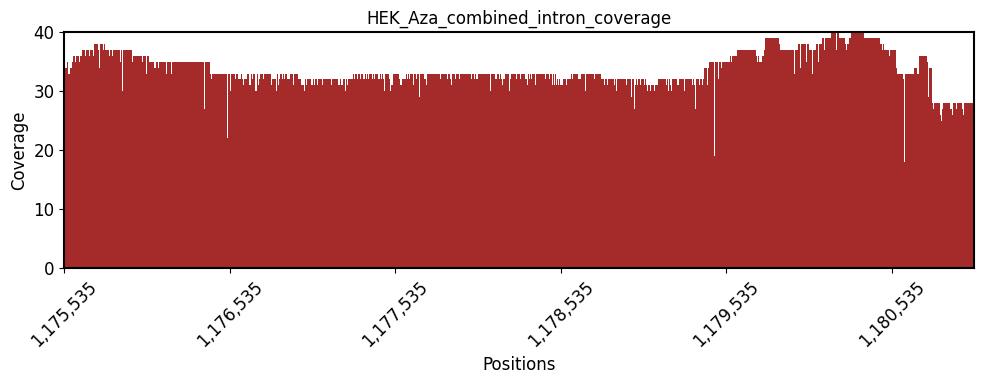

In [49]:
file = open("/media/data_01/shared/GENOMES/homo_sapiens/T2T-CHM13v2.0/genome/loc1.fa","r")

seqLoc2 = {}

count = 1175534

for line in file:
    a = list(line)
    for i in a:
        count +=1
        seqLoc2[count]=[count]
file.close()
file = "HEK_Aza_cutsitetest_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.intron.txt"
plotDepthIntron(seqLoc2,"137_LE_hTERT_CRISPR_HEK_Aza_cutsitetest/T2T/"+file,file,"HEK_Aza_combined_intron_coverage")

## Methylation

144_LE_hTERT_CRISPR_VA13_Aza/T2T/VA13_Aza_barcodetest_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.bed


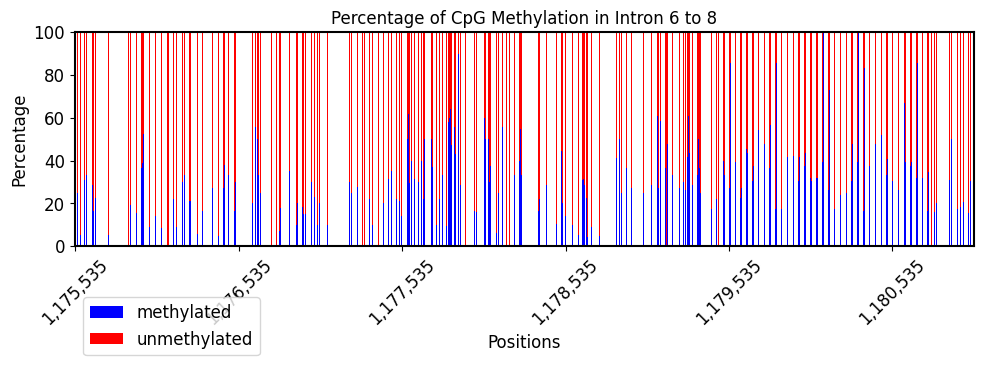

In [12]:
Intron6t8meth("144_LE_hTERT_CRISPR_VA13_Aza/T2T/VA13_Aza_barcodetest_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.bed",
             "VA13_Aza_barcodetest_intron")

137_LE_hTERT_CRISPR_HEK_Aza_cutsitetest/T2T/HEK_Aza_cutsitetest_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.bed


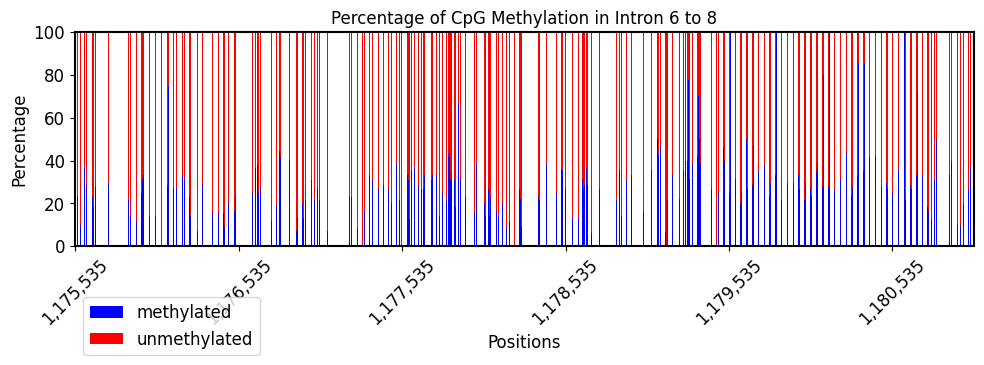

In [13]:
Intron6t8meth("137_LE_hTERT_CRISPR_HEK_Aza_cutsitetest/T2T/HEK_Aza_cutsitetest_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.bed",
             "HEK_Aza_cutsitetest_intron")

125_NDLE_hTERT_CRISPR_VA13/T2T/VA13_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bed


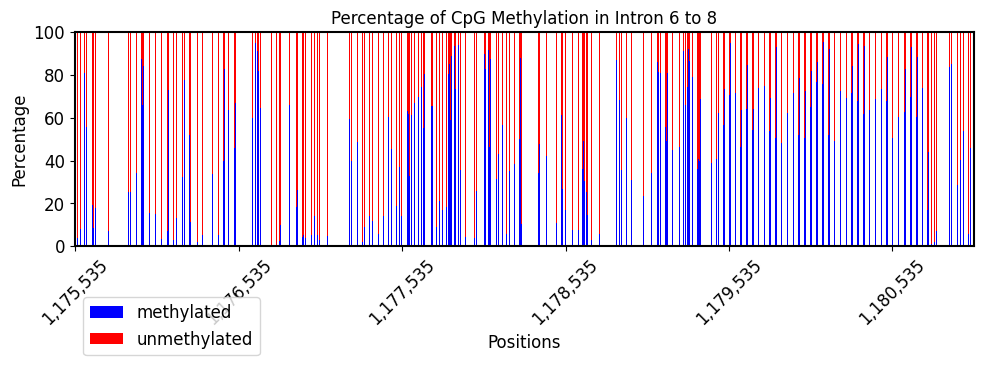

In [14]:
Intron6t8meth("125_NDLE_hTERT_CRISPR_VA13/T2T/VA13_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bed",
             "VA13_intron")

126_LE_hTERT_CRISPR_HEK_IPS/T2T/barcode22_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bed


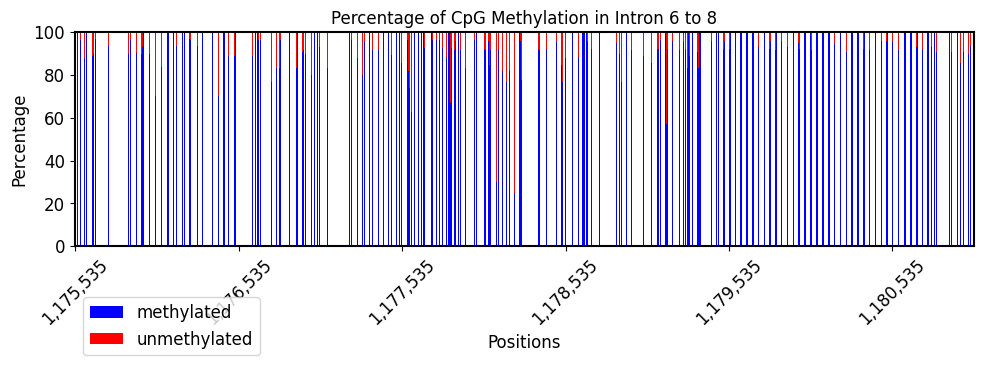

In [15]:
Intron6t8meth("126_LE_hTERT_CRISPR_HEK_IPS/T2T/barcode22_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bed",
             "HEK_293T_intron")

126_LE_hTERT_CRISPR_HEK_IPS/T2T/barcode24_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bed


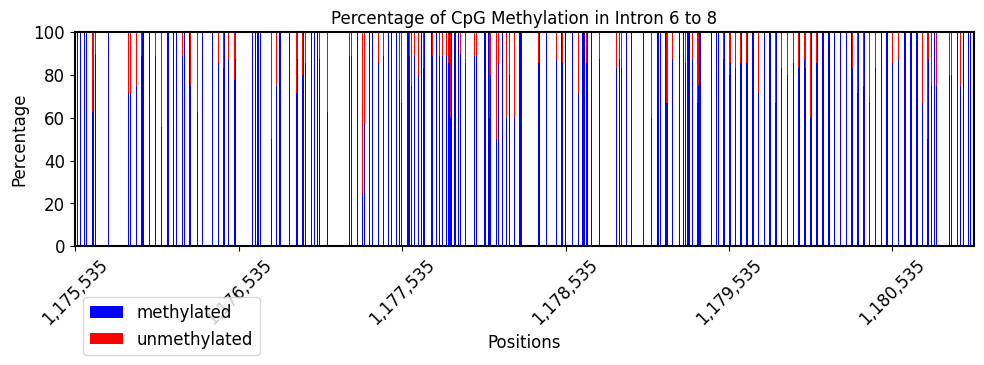

In [16]:
Intron6t8meth("126_LE_hTERT_CRISPR_HEK_IPS/T2T/barcode24_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bed",
             "HG002_IPSC_intron")

144_LE_hTERT_CRISPR_VA13_Aza/T2T/DORADO_DEMUX/b46be69c02e8f52145e7b3019738042afe7c7fff_EXP-NBD104_barcode06.bam.aligned.bam.sorted.bam.bed


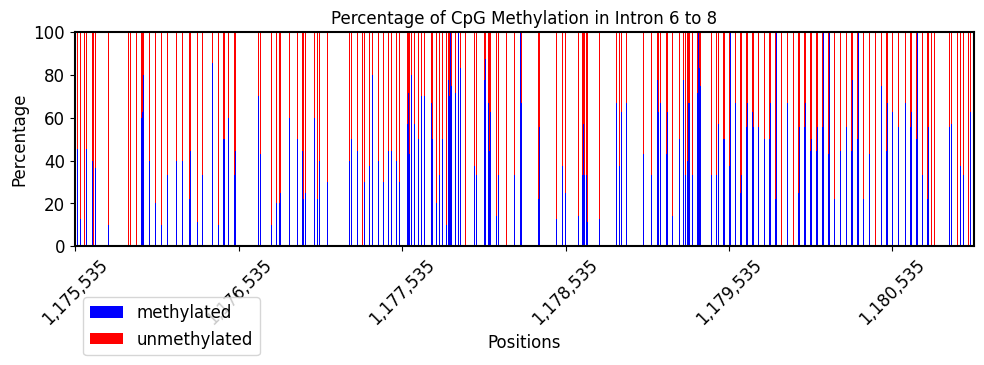

144_LE_hTERT_CRISPR_VA13_Aza/T2T/DORADO_DEMUX/b46be69c02e8f52145e7b3019738042afe7c7fff_EXP-NBD104_barcode07.bam.aligned.bam.sorted.bam.bed


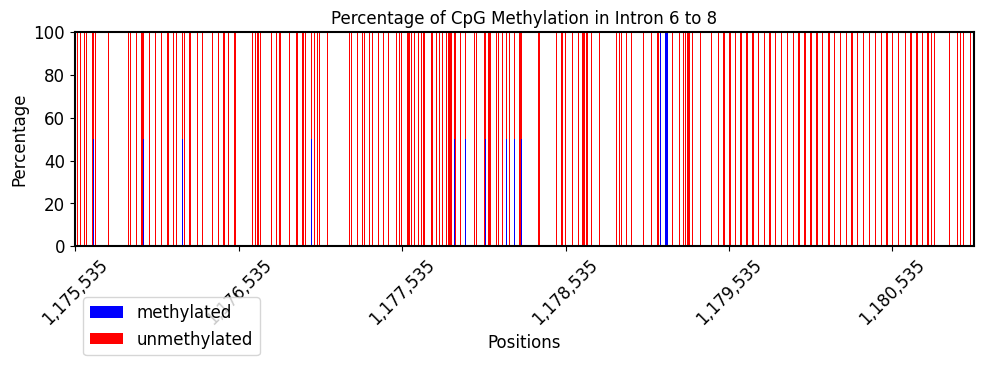

144_LE_hTERT_CRISPR_VA13_Aza/T2T/DORADO_DEMUX/b46be69c02e8f52145e7b3019738042afe7c7fff_EXP-NBD104_barcode12.bam.aligned.bam.sorted.bam.bed


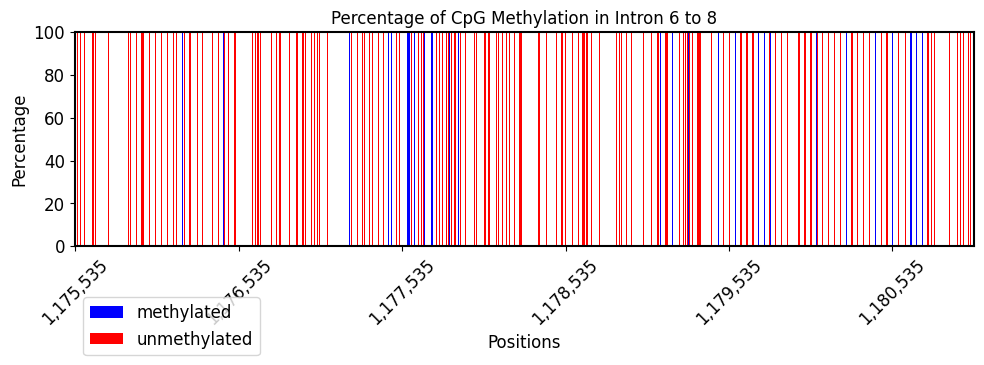

144_LE_hTERT_CRISPR_VA13_Aza/T2T/DORADO_DEMUX/b46be69c02e8f52145e7b3019738042afe7c7fff_EXP-NBD114_barcode22.bam.aligned.bam.sorted.bam.bed


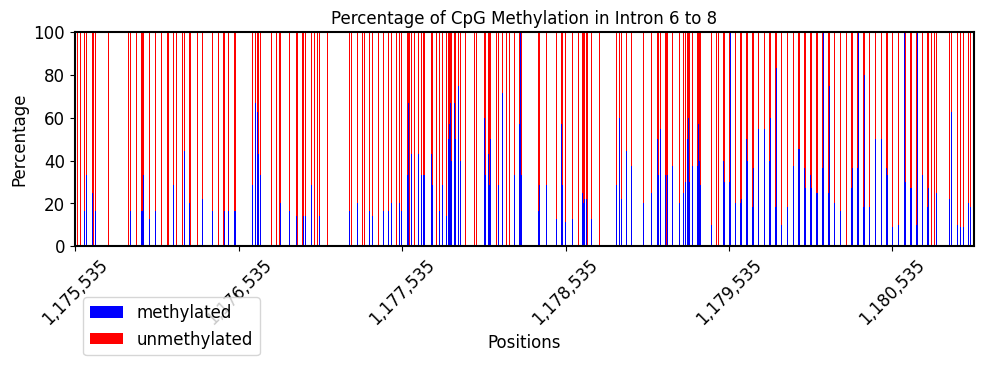

144_LE_hTERT_CRISPR_VA13_Aza/T2T/DORADO_DEMUX/b46be69c02e8f52145e7b3019738042afe7c7fff_unclassified.bam.aligned.bam.sorted.bam.bed


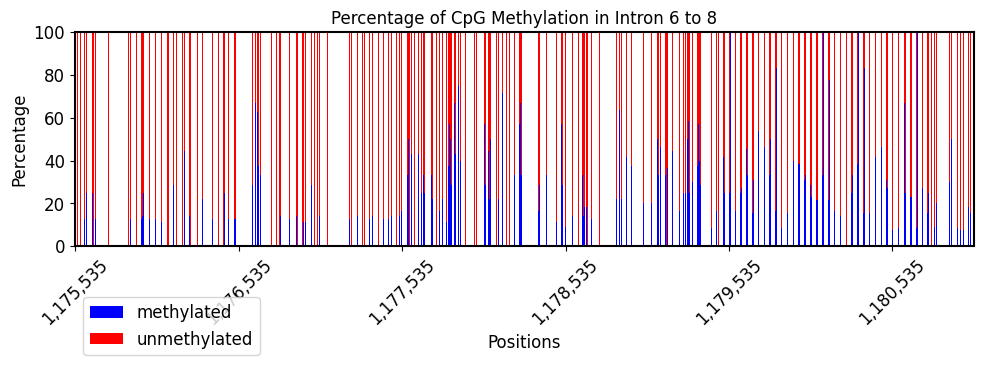

In [17]:
files = pd.read_csv("/media/data_01/vapatter/PROJECTS/15-LARS/144_LE_hTERT_CRISPR_VA13_Aza/T2T/DORADO_DEMUX/files.txt", header = None)
files = list(files[0])
for f in files:
    Intron6t8meth("144_LE_hTERT_CRISPR_VA13_Aza/T2T/DORADO_DEMUX/"+f,f+"_intron")

MERGED_HEK_24h_hTAPAS/HEK_K24.bam.sorted.bam.aligned.bam.sorted.bam.bed


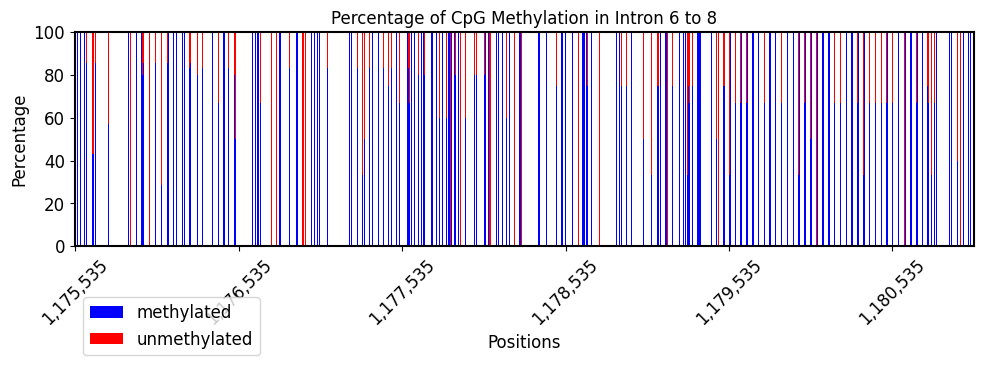

MERGED_HEK_24h_hTAPAS/HEK_K_24.bam.sorted.bam.aligned.bam.sorted.bam.bed


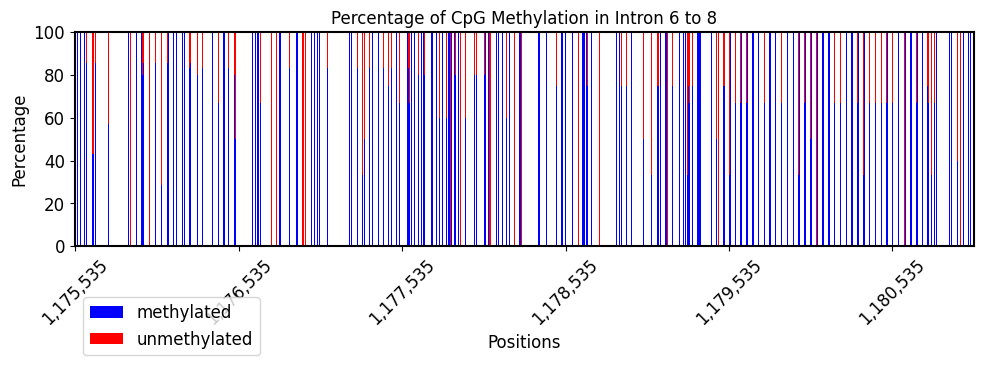

MERGED_HEK_24h_hTAPAS/HEK_S_24.bam.sorted.bam.aligned.bam.sorted.bam.bed


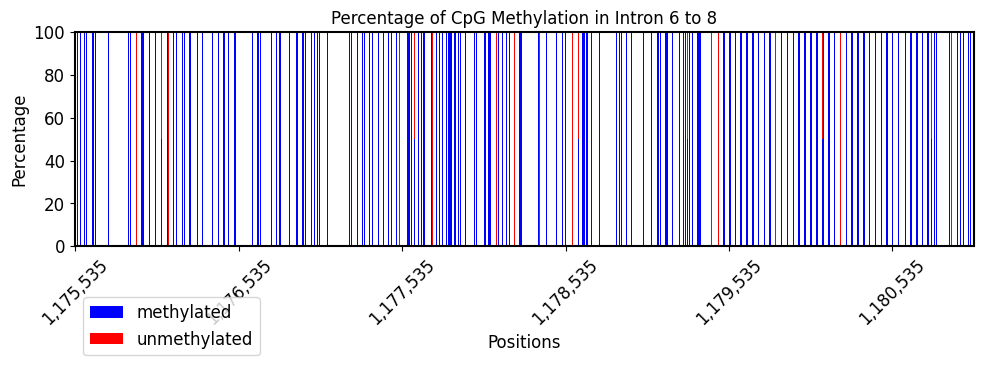

MERGED_HEK_24h_hTAPAS/HEK_T2_24.bam.sorted.bam.aligned.bam.sorted.bam.bed


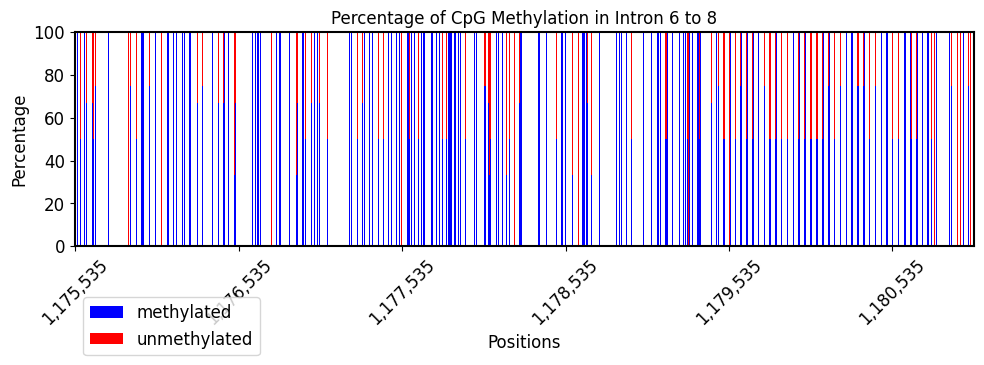

MERGED_HEK_24h_hTAPAS/HEK_TM_24.bam.sorted.bam.aligned.bam.sorted.bam.bed


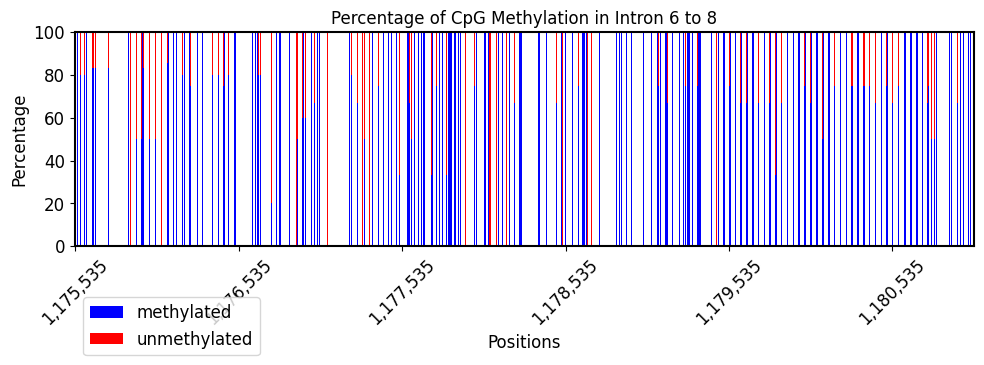

MERGED_HEK_24h_hTAPAS/HEK_T_24.bam.sorted.bam.aligned.bam.sorted.bam.bed


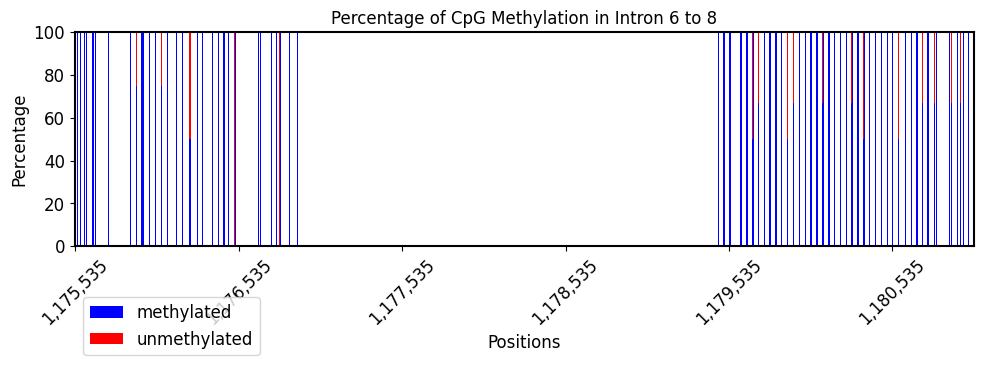

In [55]:
files = pd.read_csv("/media/data_01/vapatter/PROJECTS/15-LARS/MERGED_HEK_24h_hTAPAS/files.txt", header = None)
files = list(files[0])
for f in files:
    Intron6t8meth("MERGED_HEK_24h_hTAPAS/"+f,f+"_intron")

## Annotation

/tmp/ipykernel_49182/16471449.py:68: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


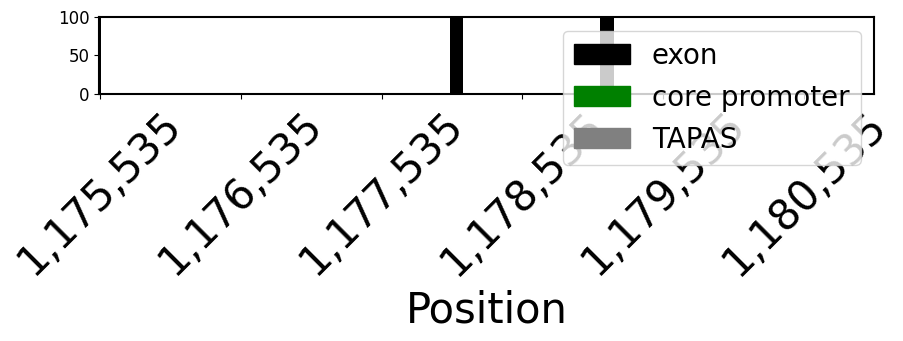

In [37]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patheffects as mpe
import matplotlib.patches as mpatches

file = open("/media/data_01/shared/GENOMES/homo_sapiens/T2T-CHM13v2.0/genome/loc1.fa","r")
annot = {}
count = 1175534

for line in file:
    a = list(line)
    for i in a:
        count +=1
        annot[count]=0
file.close()

# Define regions to color-code
for k,v in annot.items():
    if k >=1175535 and k<=1175540:
        annot[k]=100
    elif k >=1178026 and k<=1178110:
        annot[k]=100
    elif k >=1179092 and k<=1179186:
        annot[k]=100

# Set up the plot
fig = plt.gcf()
fig.set_size_inches(10, 1)
plt.rcParams.update({'font.size': 12})
outline = mpe.withStroke(linewidth=8, foreground='black')

# Extract x labels and y values
x_labels = list(annot.keys())
y1_values = [float(val) for val in annot.values()]
x = np.arange(len(x_labels))

# Define color map based on y1_values
colors = ['black' if y == 100 else 'green' if y == 50 else 'grey' if y == 25 else 'blue' for y in y1_values]

# Plot the bars with color coding
plt.bar(x, y1_values, color=colors, align='center', width=5)

# Add legend for color codes
black_patch = mpatches.Patch(color='black', label='exon')
green_patch = mpatches.Patch(color='green', label='core promoter')
grey_patch = mpatches.Patch(color='grey', label='TAPAS')
#blue_patch = mpatches.Patch(color='blue', label='Other')

plt.legend(handles=[black_patch, green_patch, grey_patch], fontsize=20, loc="upper right")

# Customize ticks and labels
tick_positions = np.arange(0, len(x_labels), 1000)
tick_labels = [f"{int(x_labels[i]):,}" for i in tick_positions]
plt.xticks(tick_positions, tick_labels, rotation=45, fontsize=30)
plt.xlabel("Position", fontsize=30)

# Add a border around the plot
plt.gca().spines['top'].set_linewidth(1.5)
plt.gca().spines['right'].set_linewidth(1.5)
plt.gca().spines['bottom'].set_linewidth(1.5)
plt.gca().spines['left'].set_linewidth(1.5)
plt.margins(0)

# Save the figure
plt.savefig("/media/data_01/vapatter/PROJECTS/15-LARS/PDF/Intron6to8Annotation.pdf", format="pdf", bbox_inches="tight")

# Show plot
plt.tight_layout()
plt.show()


# TAPAS

## Coverage

In [12]:
%%bash
cd /media/data_01/vapatter/PROJECTS/15-LARS/144_LE_hTERT_CRISPR_VA13_Aza/T2T/
for f in *sorted.bam; do 
ls $f
samtools depth -r NC_060929.1:1196006-1205278 $f | awk '
{
    sum += $3;                          # Sum of depths
    sumsq += $3 * $3;                   # Sum of squares of depths
    count++;                             # Count of positions
}
END {
    if (count > 0) {
        avg = sum / count;               # Average depth
        variance = (sumsq / count) - (avg * avg);  # Variance
        stddev = (variance > 0) ? sqrt(variance) : 0;  # Standard deviation
        print "Average depth:", avg;
        print "Standard deviation:", stddev;
    } else {
        print "No data";
    }
}'
samtools view -F 4 $f NC_060929.1:1196006-1205278 | wc -l
samtools view -F 4 -F 256 $f NC_060929.1:1196006-1205278 | wc -l; done

VA13_Aza_barcodetest_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam
Average depth: 90.8854
Standard deviation: 6.92027
232
218


In [16]:
%%bash
cd /media/data_01/vapatter/PROJECTS/15-LARS/144_LE_hTERT_CRISPR_VA13_Aza/T2T/DORADO_DEMUX
for f in *sorted.bam; do 
ls $f
samtools depth -r NC_060929.1:1196006-1205278 $f | awk '
{
    sum += $3;                          # Sum of depths
    sumsq += $3 * $3;                   # Sum of squares of depths
    count++;                             # Count of positions
}
END {
    if (count > 0) {
        avg = sum / count;               # Average depth
        variance = (sumsq / count) - (avg * avg);  # Variance
        stddev = (variance > 0) ? sqrt(variance) : 0;  # Standard deviation
        print "Average depth:", avg;
        print "Standard deviation:", stddev;
    } else {
        print "No data";
    }
}'
samtools view -F 4 $f NC_060929.1:1196006-1205278 | wc -l
samtools view -F 4 -F 256 $f NC_060929.1:1196006-1205278 | wc -l; done

b46be69c02e8f52145e7b3019738042afe7c7fff_EXP-NBD104_barcode06.bam.aligned.bam.sorted.bam
Average depth: 50.7294
Standard deviation: 3.69596
65
64
b46be69c02e8f52145e7b3019738042afe7c7fff_EXP-NBD104_barcode07.bam.aligned.bam.sorted.bam
Average depth: 19.6667
Standard deviation: 1.30552
23
23
b46be69c02e8f52145e7b3019738042afe7c7fff_EXP-NBD104_barcode12.bam.aligned.bam.sorted.bam
Average depth: 3.48884
Standard deviation: 0.762197
6
6
b46be69c02e8f52145e7b3019738042afe7c7fff_EXP-NBD114_barcode22.bam.aligned.bam.sorted.bam
Average depth: 11.6352
Standard deviation: 3.17743
86
86
b46be69c02e8f52145e7b3019738042afe7c7fff_unclassified.bam.aligned.bam.sorted.bam
Average depth: 17.0004
Standard deviation: 3.29157
138
125


In [ ]:
%%bash
cd /media/data_01/vapatter/PROJECTS/15-LARS/144_LE_hTERT_CRISPR_VA13_Aza/T2T/DORADO_DEMUX
for f in *.bam.aligned.bam.sorted.bam; 
do samtools depth -Q 0 -b locations2.bed -o $f.hTAPAS_coverage.txt $f; done

b46be69c02e8f52145e7b3019738042afe7c7fff_EXP-NBD104_barcode06.bam.aligned.bam.sorted.bam.hTAPAS_coverage.txt


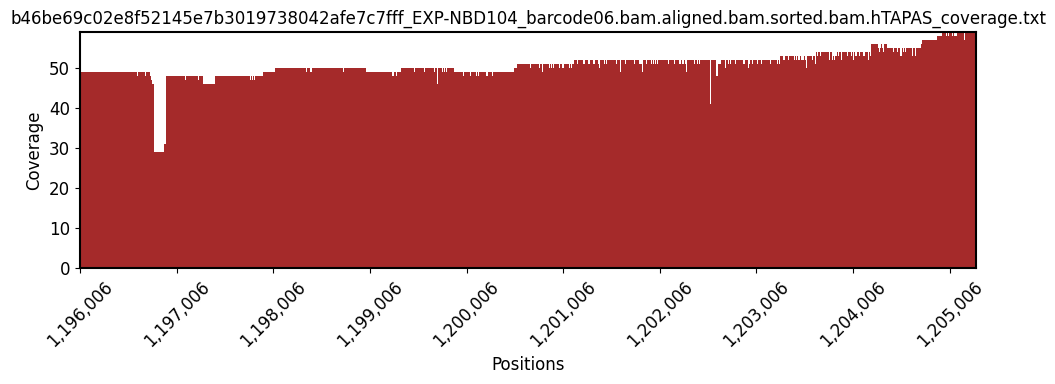

b46be69c02e8f52145e7b3019738042afe7c7fff_EXP-NBD104_barcode07.bam.aligned.bam.sorted.bam.hTAPAS_coverage.txt


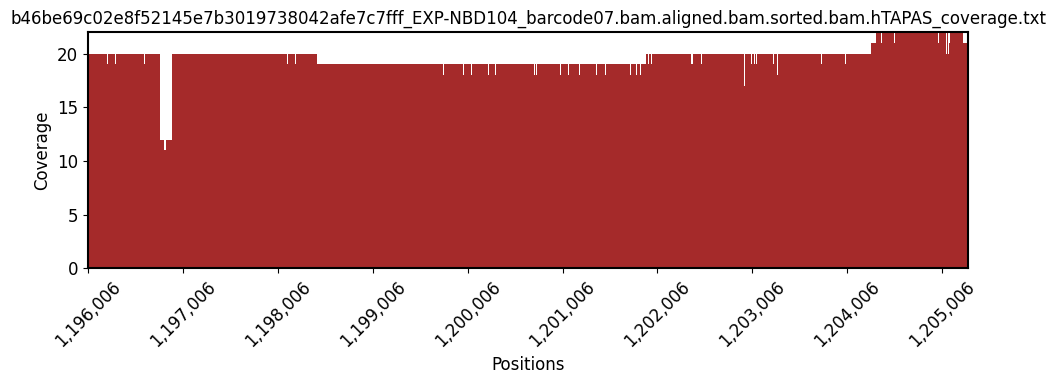

b46be69c02e8f52145e7b3019738042afe7c7fff_EXP-NBD104_barcode12.bam.aligned.bam.sorted.bam.hTAPAS_coverage.txt


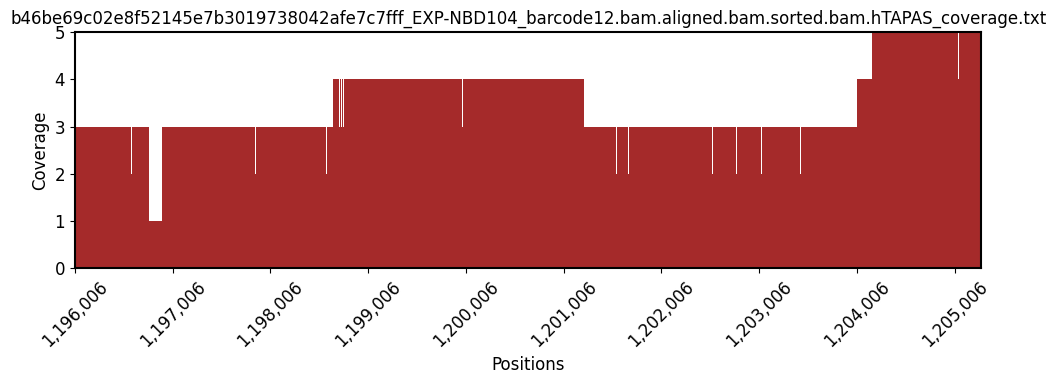

b46be69c02e8f52145e7b3019738042afe7c7fff_EXP-NBD114_barcode22.bam.aligned.bam.sorted.bam.hTAPAS_coverage.txt


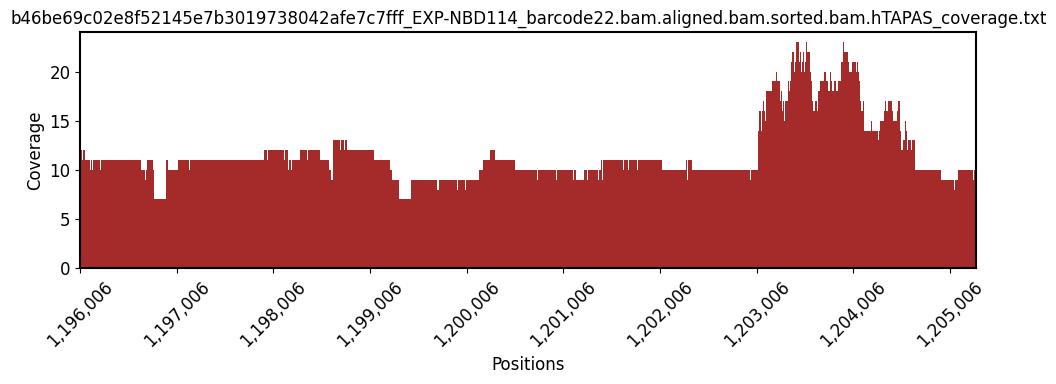

b46be69c02e8f52145e7b3019738042afe7c7fff_unclassified.bam.aligned.bam.sorted.bam.hTAPAS_coverage.txt


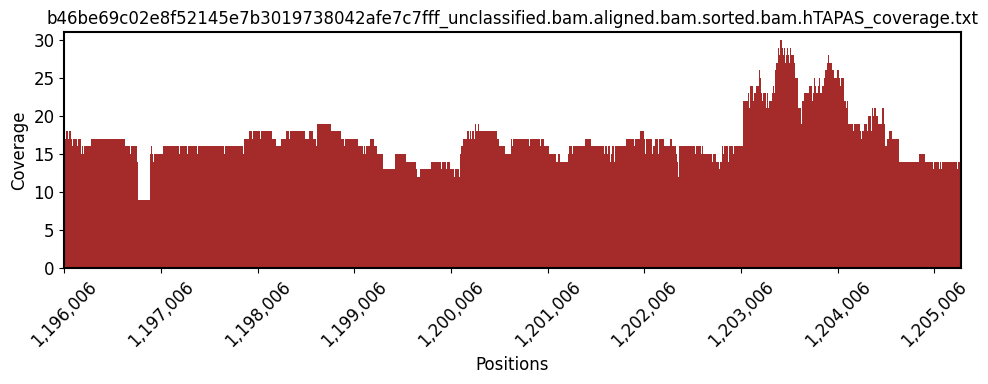

In [63]:
file = open("/media/data_01/shared/GENOMES/homo_sapiens/T2T-CHM13v2.0/genome/loc2.fa","r")

seqLoc2 = {}

count = 1196005

for line in file:
    a = list(line)
    for i in a:
        count +=1
        seqLoc2[count]=[count]
file.close()
files = pd.read_csv("/media/data_01/vapatter/PROJECTS/15-LARS/144_LE_hTERT_CRISPR_VA13_Aza/T2T/DORADO_DEMUX/coveragesTAPAS.txt", header = None)
files = list(files[0])
for f in files:
    plotDepthTAPAS(seqLoc2,"144_LE_hTERT_CRISPR_VA13_Aza/T2T/DORADO_DEMUX/"+f,f,f)

HEK_K24.bam.sorted.bam.aligned.bam.sorted.bam.hTAPAS.txt


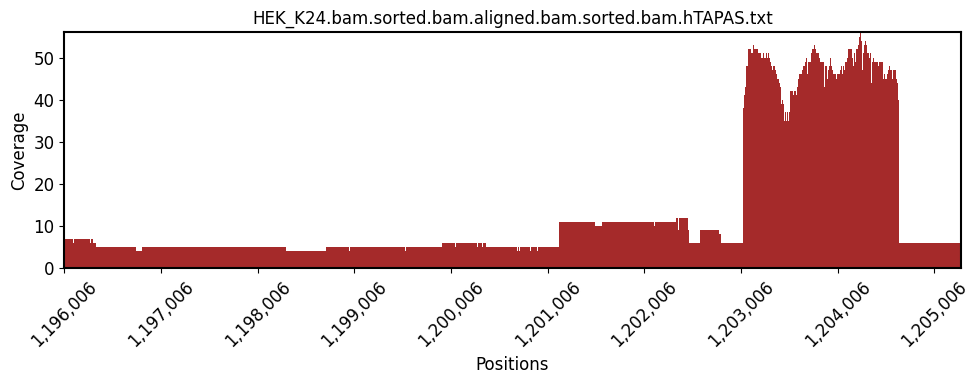

HEK_K24.bam.sorted.bam.hTAPAS.txt


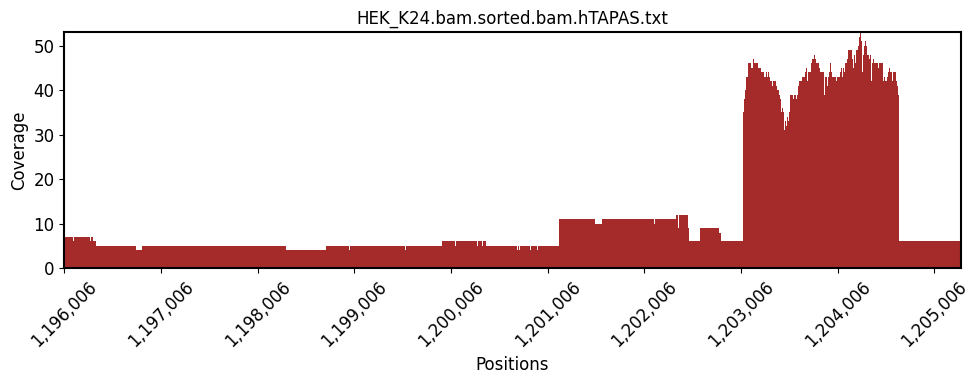

HEK_K_24.bam.sorted.bam.aligned.bam.sorted.bam.hTAPAS.txt


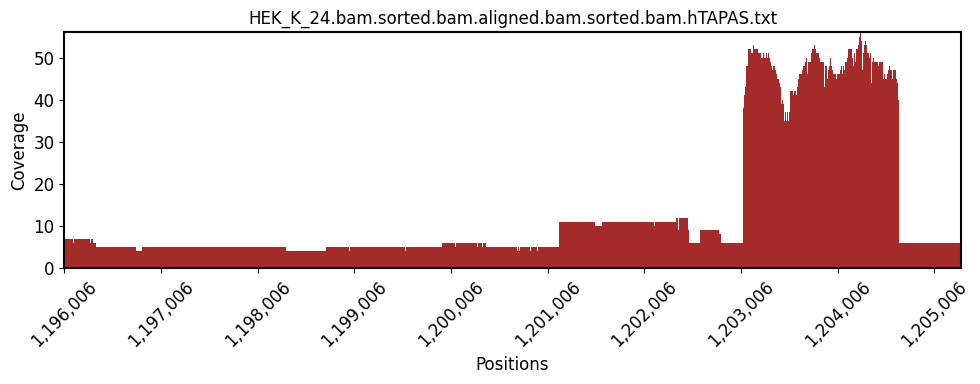

HEK_K_24.bam.sorted.bam.hTAPAS.txt


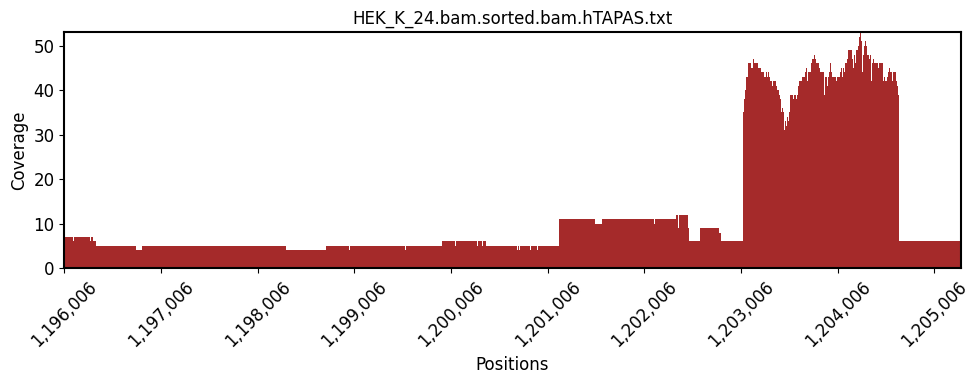

HEK_S_24.bam.sorted.bam.aligned.bam.sorted.bam.hTAPAS.txt


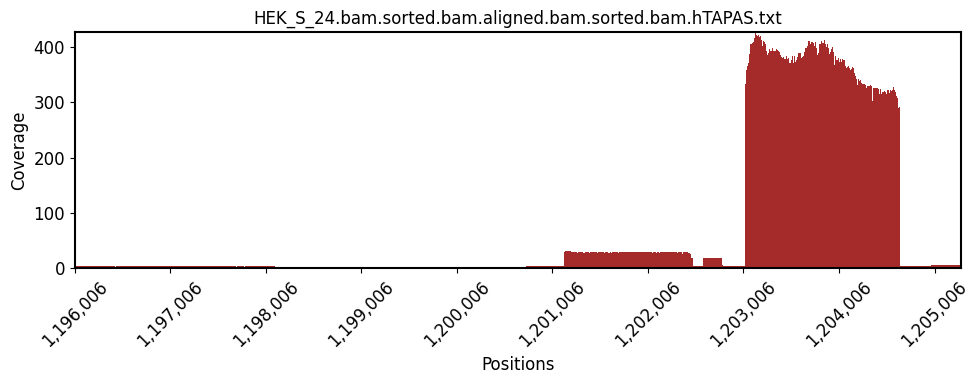

HEK_S_24.bam.sorted.bam.hTAPAS.txt


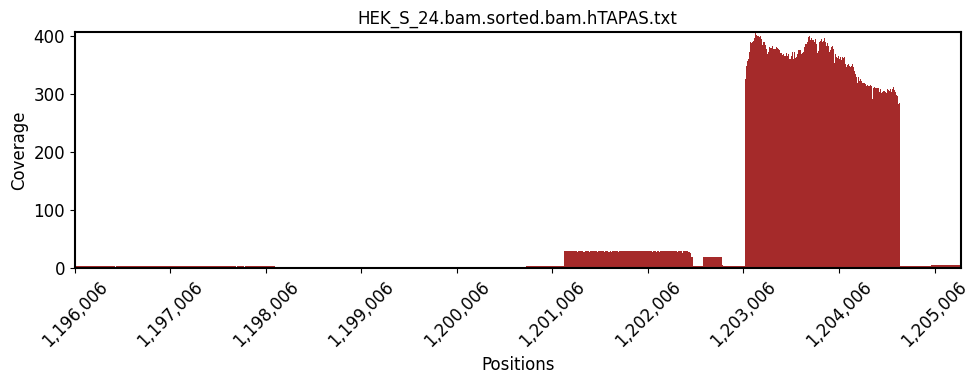

HEK_T2_24.bam.sorted.bam.aligned.bam.sorted.bam.hTAPAS.txt


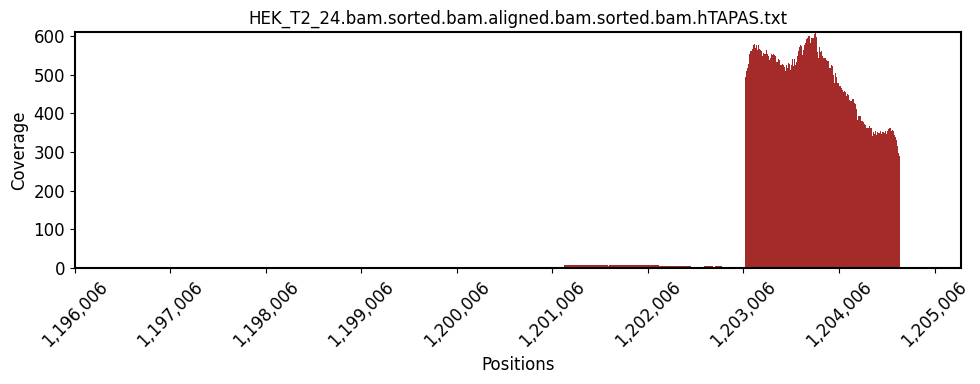

HEK_T2_24.bam.sorted.bam.hTAPAS.txt


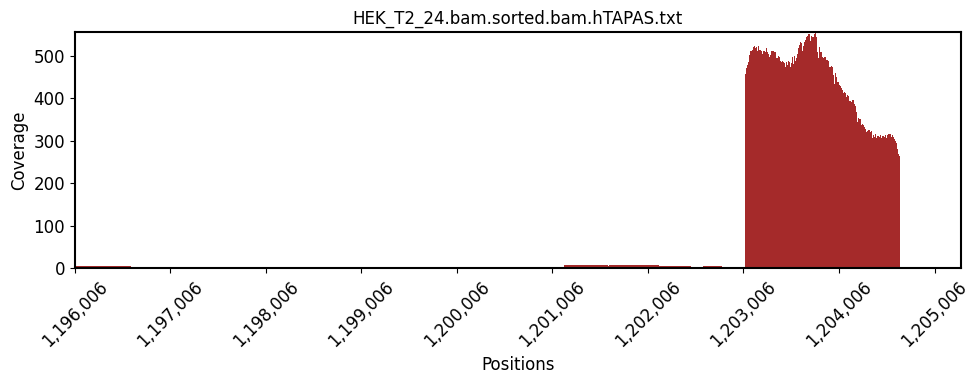

HEK_TM_24.bam.sorted.bam.aligned.bam.sorted.bam.hTAPAS.txt


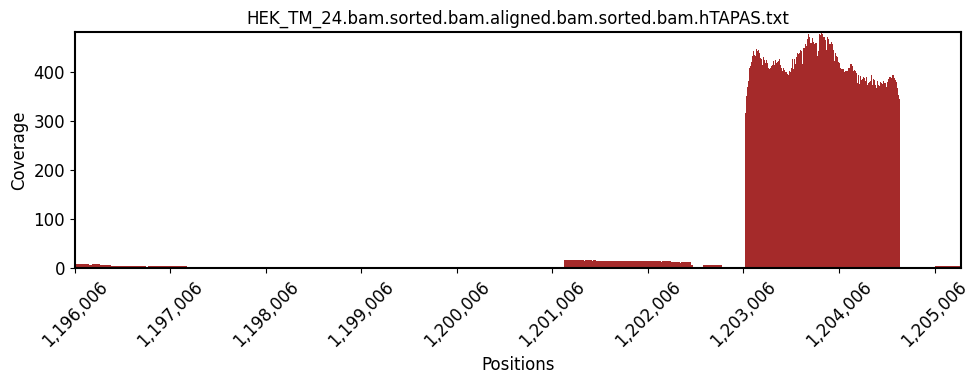

HEK_TM_24.bam.sorted.bam.hTAPAS.txt


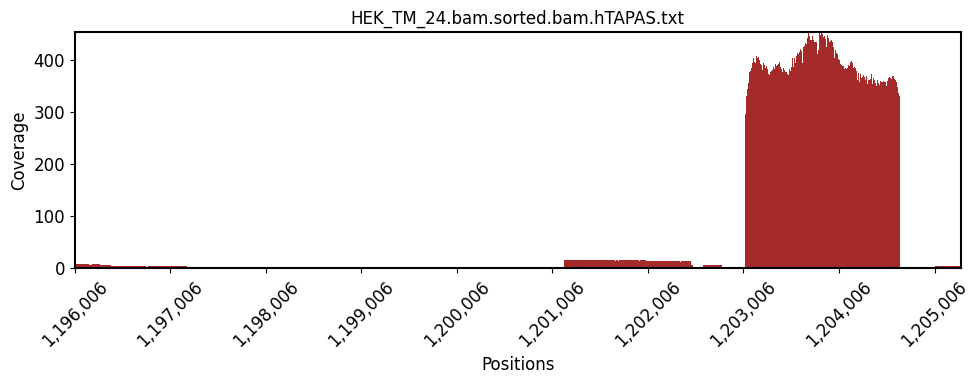

HEK_T_24.bam.sorted.bam.aligned.bam.sorted.bam.hTAPAS.txt


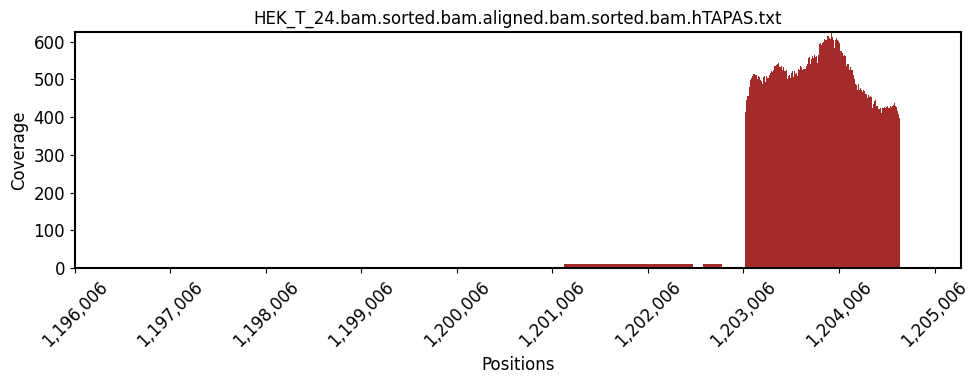

HEK_T_24.bam.sorted.bam.hTAPAS.txt


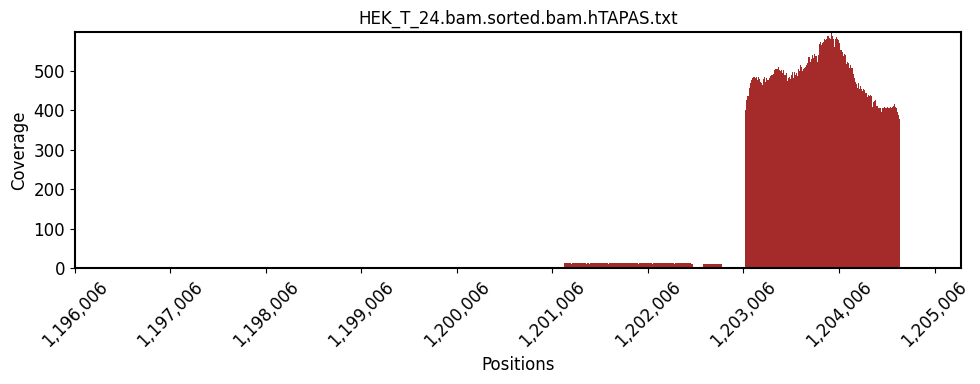

In [58]:
file = open("/media/data_01/shared/GENOMES/homo_sapiens/T2T-CHM13v2.0/genome/loc2.fa","r")

seqLoc2 = {}

count = 1196005

for line in file:
    a = list(line)
    for i in a:
        count +=1
        seqLoc2[count]=[count]
file.close()
files = pd.read_csv("/media/data_01/vapatter/PROJECTS/15-LARS/MERGED_HEK_24h_hTAPAS/coverage_hTAPAS.txt", header = None)
files = list(files[0])
for f in files:
    plotDepthTAPAS(seqLoc2,"MERGED_HEK_24h_hTAPAS/"+f,f,f)

VA13_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.hTAPAS.txt


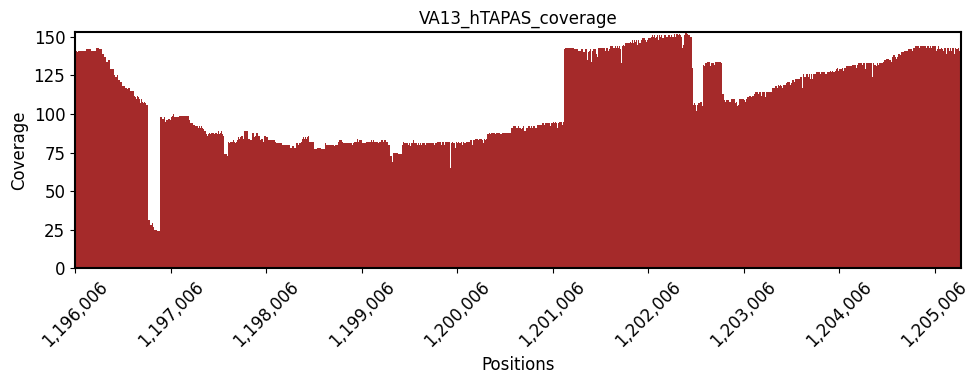

In [50]:
file = open("/media/data_01/shared/GENOMES/homo_sapiens/T2T-CHM13v2.0/genome/loc2.fa","r")

seqLoc2 = {}

count = 1196005

for line in file:
    a = list(line)
    for i in a:
        count +=1
        seqLoc2[count]=[count]
file.close()
file = "VA13_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.hTAPAS.txt"
plotDepthTAPAS(seqLoc2,"125_NDLE_hTERT_CRISPR_VA13/T2T/"+file,file,"VA13_hTAPAS_coverage")

barcode24_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.hTAPAS.txt


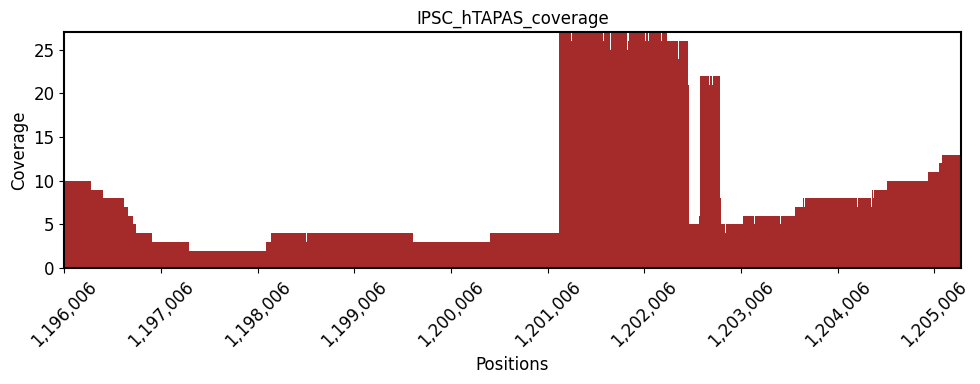

In [51]:
file = open("/media/data_01/shared/GENOMES/homo_sapiens/T2T-CHM13v2.0/genome/loc2.fa","r")

seqLoc2 = {}

count = 1196005

for line in file:
    a = list(line)
    for i in a:
        count +=1
        seqLoc2[count]=[count]
file.close()
file = "barcode24_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.hTAPAS.txt"
plotDepthTAPAS(seqLoc2,"126_LE_hTERT_CRISPR_HEK_IPS/T2T/"+file,file,"IPSC_hTAPAS_coverage")

barcode22_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.hTAPAS.txt


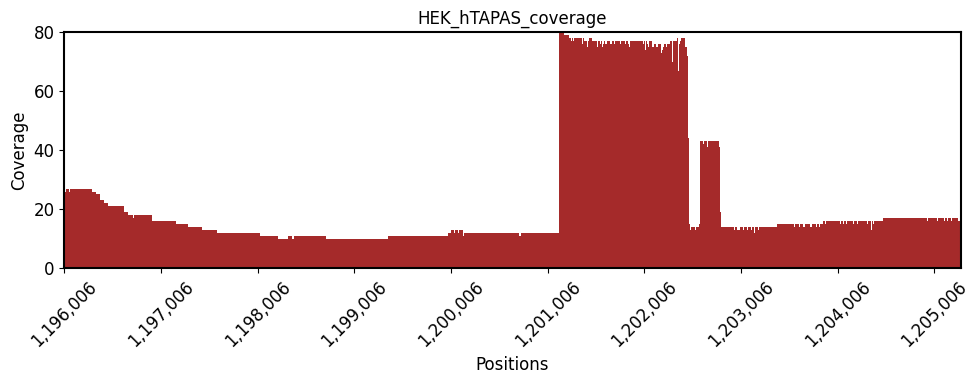

In [52]:
file = open("/media/data_01/shared/GENOMES/homo_sapiens/T2T-CHM13v2.0/genome/loc2.fa","r")

seqLoc2 = {}

count = 1196005

for line in file:
    a = list(line)
    for i in a:
        count +=1
        seqLoc2[count]=[count]
file.close()
file = "barcode22_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.hTAPAS.txt"
plotDepthTAPAS(seqLoc2,"126_LE_hTERT_CRISPR_HEK_IPS/T2T/"+file,file,"HEK_hTAPAS_coverage")

HEK_Aza_cutsitetest_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.hTAPAS.txt


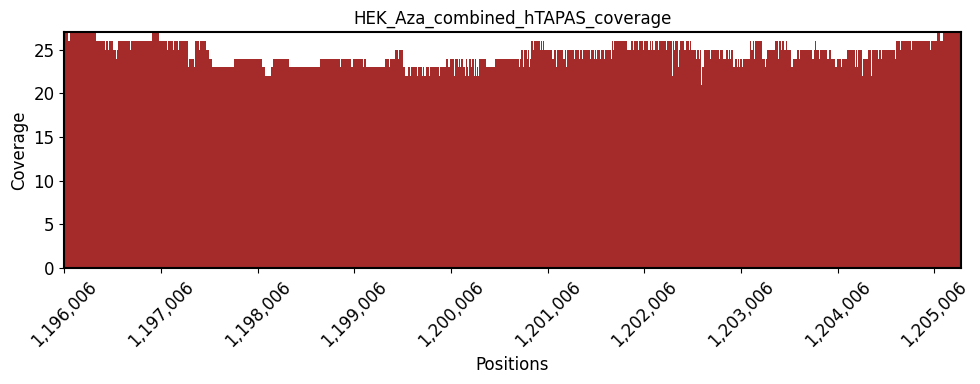

In [53]:
file = open("/media/data_01/shared/GENOMES/homo_sapiens/T2T-CHM13v2.0/genome/loc2.fa","r")

seqLoc2 = {}

count = 1196005

for line in file:
    a = list(line)
    for i in a:
        count +=1
        seqLoc2[count]=[count]
file.close()
file = "HEK_Aza_cutsitetest_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.hTAPAS.txt"
plotDepthTAPAS(seqLoc2,"137_LE_hTERT_CRISPR_HEK_Aza_cutsitetest/T2T/"+file,file,"HEK_Aza_combined_hTAPAS_coverage")

## Methylation

144_LE_hTERT_CRISPR_VA13_Aza/T2T/VA13_Aza_barcodetest_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.bed


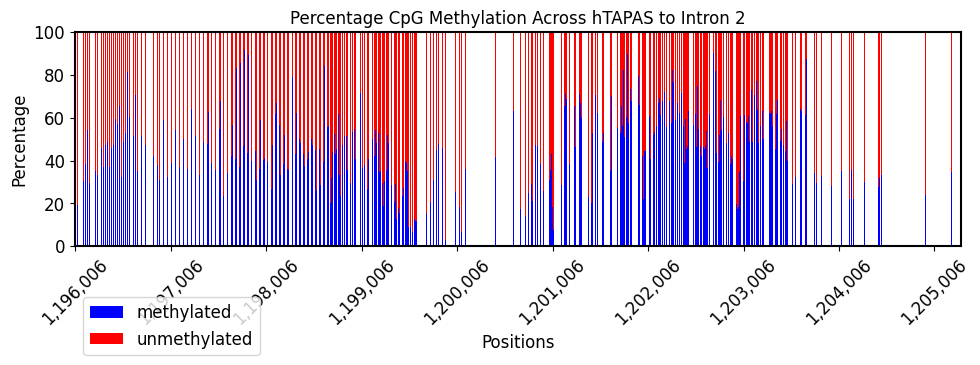

In [17]:
TAPASmeth("144_LE_hTERT_CRISPR_VA13_Aza/T2T/VA13_Aza_barcodetest_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.bed",
         "VA13_Aza_barcodetest_hTAPAS")

137_LE_hTERT_CRISPR_HEK_Aza_cutsitetest/T2T/HEK_Aza_cutsitetest_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.bed


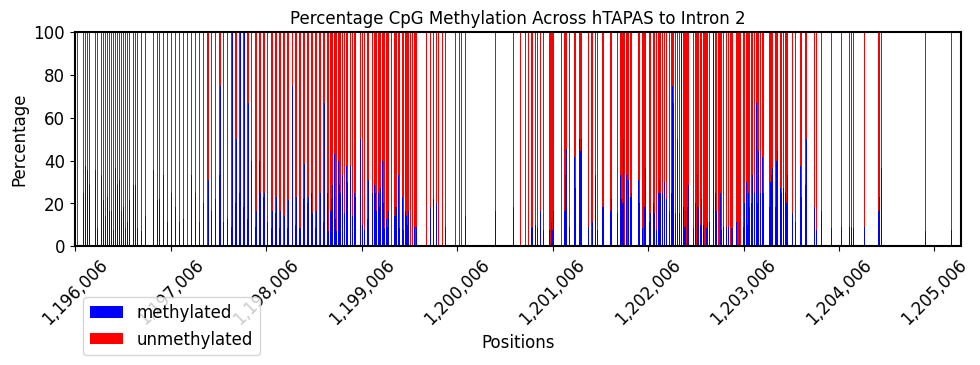

In [18]:
TAPASmeth("137_LE_hTERT_CRISPR_HEK_Aza_cutsitetest/T2T/HEK_Aza_cutsitetest_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.bed",
             "HEK_Aza_cutsitetest_hTAPAS")

126_LE_hTERT_CRISPR_HEK_IPS/T2T/barcode22_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bed


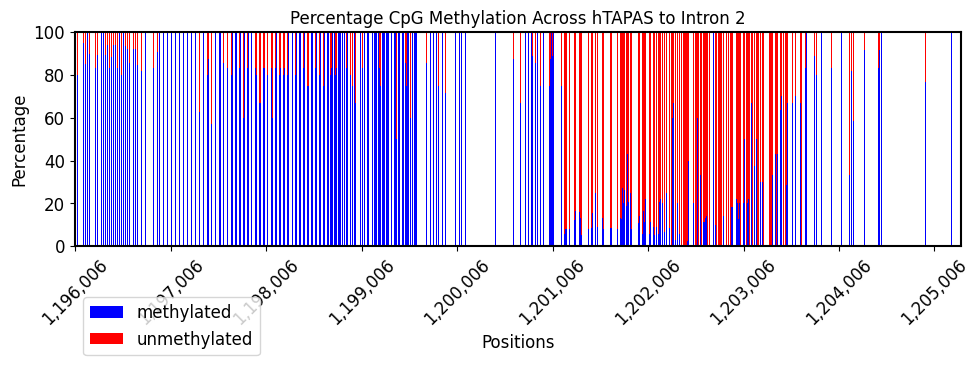

In [19]:
TAPASmeth("126_LE_hTERT_CRISPR_HEK_IPS/T2T/barcode22_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bed",
             "HEK_293T_hTAPAS")

126_LE_hTERT_CRISPR_HEK_IPS/T2T/barcode24_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bed


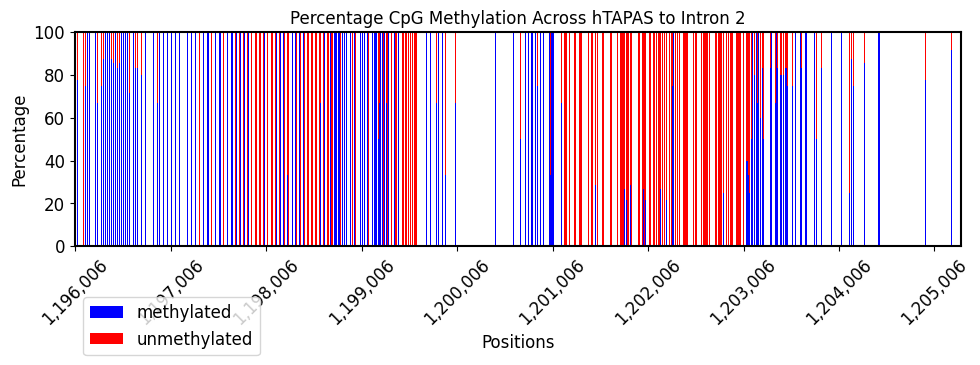

In [20]:
TAPASmeth("126_LE_hTERT_CRISPR_HEK_IPS/T2T/barcode24_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bed",
             "HG002_IPSC_hTAPAS")

125_NDLE_hTERT_CRISPR_VA13/T2T/VA13_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bed


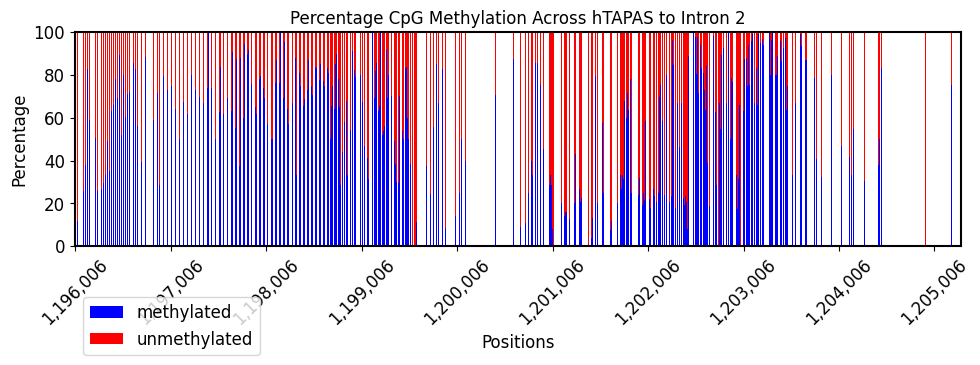

In [21]:
TAPASmeth("125_NDLE_hTERT_CRISPR_VA13/T2T/VA13_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bed",
             "VA13_hTAPAS_hTAPAS")

144_LE_hTERT_CRISPR_VA13_Aza/T2T/DORADO_DEMUX/b46be69c02e8f52145e7b3019738042afe7c7fff_EXP-NBD104_barcode06.bam.aligned.bam.sorted.bam.bed


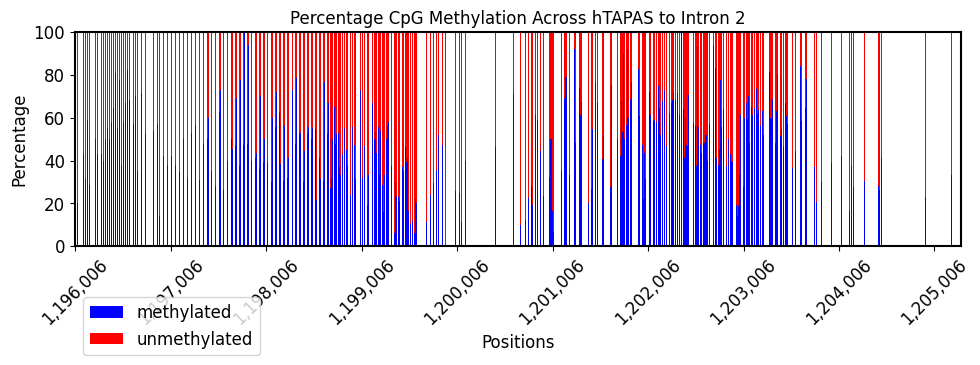

144_LE_hTERT_CRISPR_VA13_Aza/T2T/DORADO_DEMUX/b46be69c02e8f52145e7b3019738042afe7c7fff_EXP-NBD104_barcode07.bam.aligned.bam.sorted.bam.bed


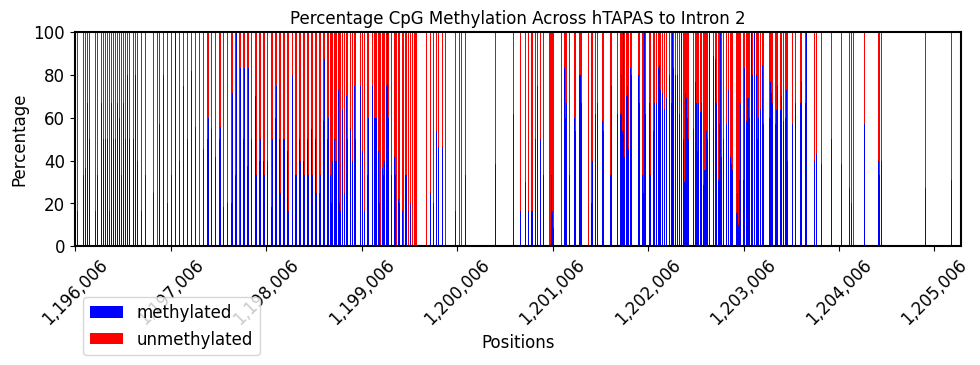

144_LE_hTERT_CRISPR_VA13_Aza/T2T/DORADO_DEMUX/b46be69c02e8f52145e7b3019738042afe7c7fff_EXP-NBD104_barcode12.bam.aligned.bam.sorted.bam.bed


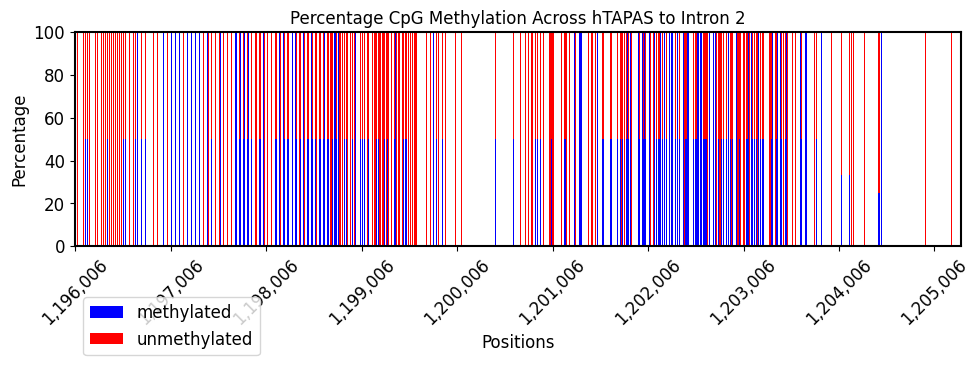

144_LE_hTERT_CRISPR_VA13_Aza/T2T/DORADO_DEMUX/b46be69c02e8f52145e7b3019738042afe7c7fff_EXP-NBD114_barcode22.bam.aligned.bam.sorted.bam.bed


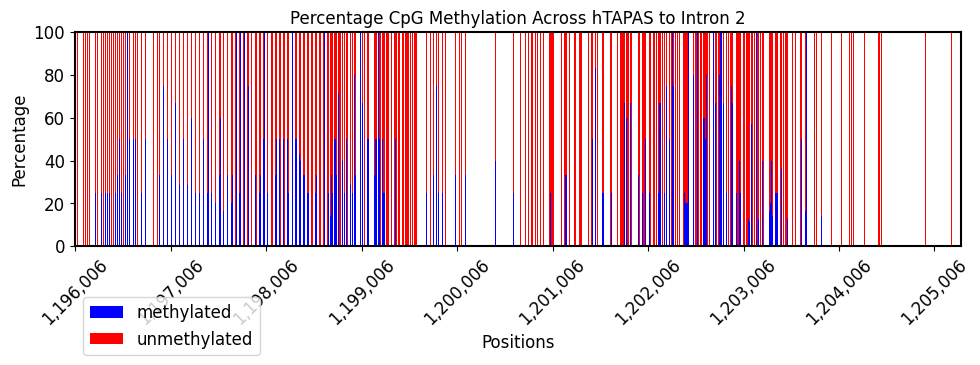

144_LE_hTERT_CRISPR_VA13_Aza/T2T/DORADO_DEMUX/b46be69c02e8f52145e7b3019738042afe7c7fff_unclassified.bam.aligned.bam.sorted.bam.bed


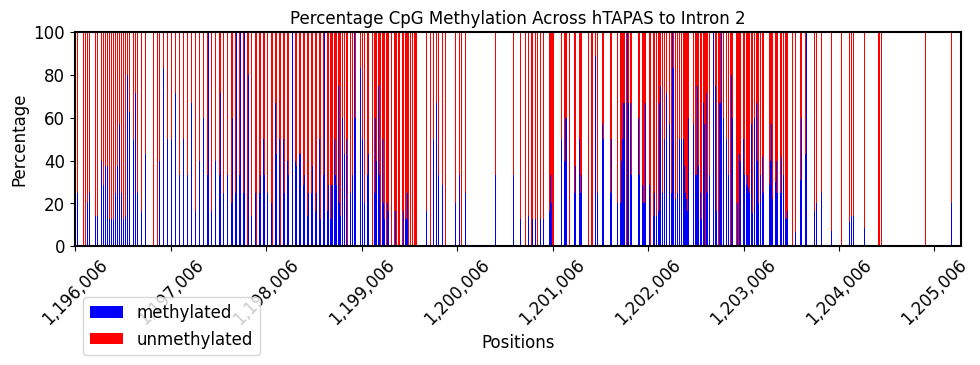

In [22]:
files = pd.read_csv("/media/data_01/vapatter/PROJECTS/15-LARS/144_LE_hTERT_CRISPR_VA13_Aza/T2T/DORADO_DEMUX/files.txt", header = None)
files = list(files[0])
for f in files:
    TAPASmeth("144_LE_hTERT_CRISPR_VA13_Aza/T2T/DORADO_DEMUX/"+f,f+"_hTAPAS")

MERGED_HEK_24h_hTAPAS/HEK_K24.bam.sorted.bam.aligned.bam.sorted.bam.bed


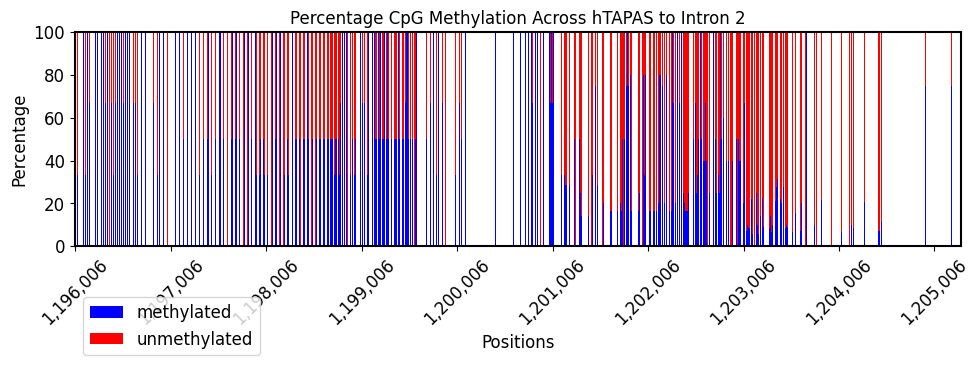

MERGED_HEK_24h_hTAPAS/HEK_K_24.bam.sorted.bam.aligned.bam.sorted.bam.bed


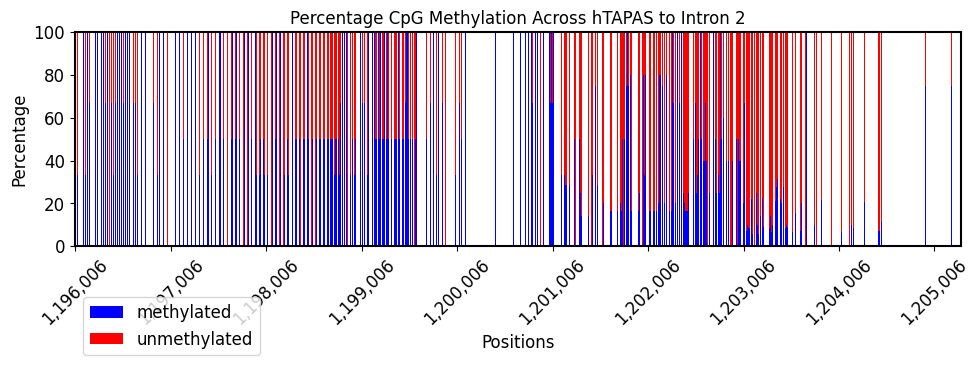

MERGED_HEK_24h_hTAPAS/HEK_S_24.bam.sorted.bam.aligned.bam.sorted.bam.bed


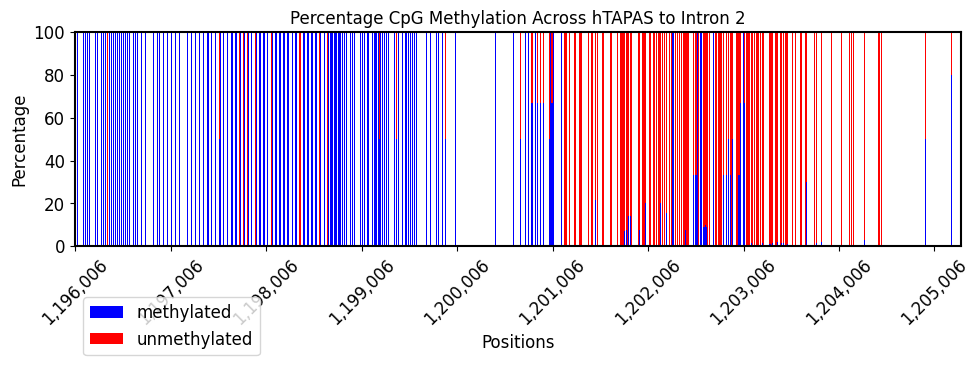

MERGED_HEK_24h_hTAPAS/HEK_T2_24.bam.sorted.bam.aligned.bam.sorted.bam.bed


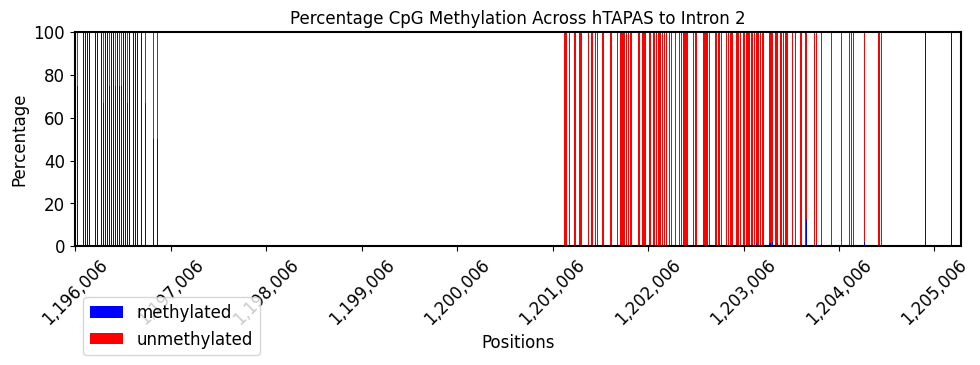

MERGED_HEK_24h_hTAPAS/HEK_TM_24.bam.sorted.bam.aligned.bam.sorted.bam.bed


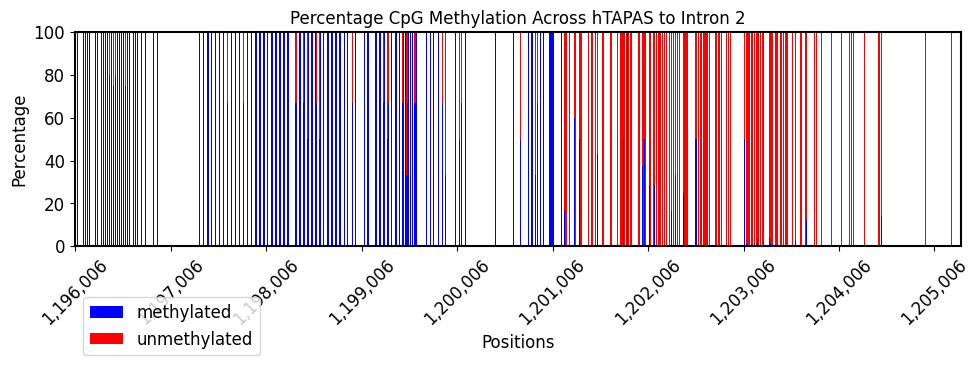

MERGED_HEK_24h_hTAPAS/HEK_T_24.bam.sorted.bam.aligned.bam.sorted.bam.bed


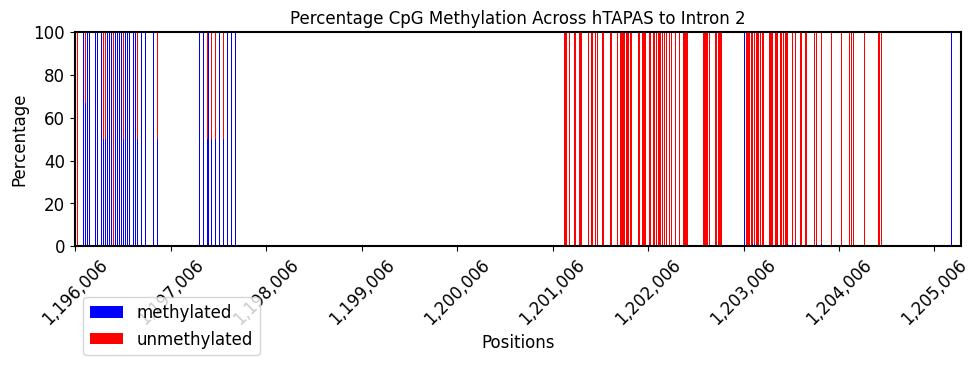

In [56]:
files = pd.read_csv("/media/data_01/vapatter/PROJECTS/15-LARS/MERGED_HEK_24h_hTAPAS/RGED_HEK_24h_hTAPAS/RGED_HEK_24h_hTAPAS/files.txt", header = None)
files = list(files[0])
for f in files:
    TAPASmeth("MERGED_HEK_24h_hTAPAS/"+f,f+"_hTAPAS")

## Annotation

/tmp/ipykernel_49182/1907954382.py:71: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


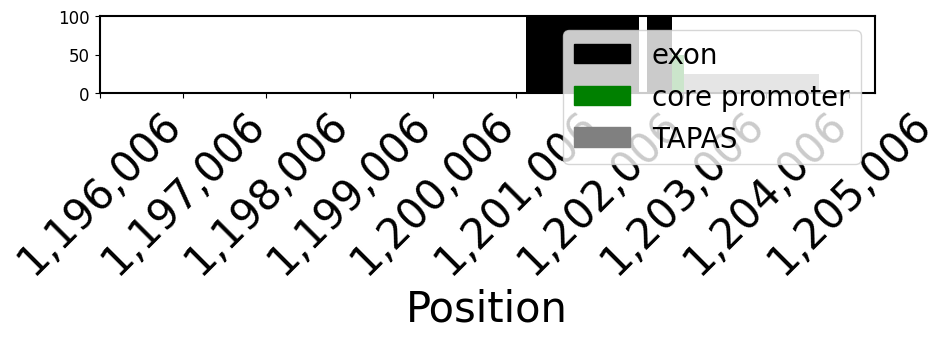

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patheffects as mpe
import matplotlib.patches as mpatches

# Initialize annot dictionary
file = open("/media/data_01/shared/GENOMES/homo_sapiens/T2T-CHM13v2.0/genome/loc2.fa", "r")
annot = {}
count = 1196005

for line in file:
    a = list(line)
    for i in a:
        count += 1
        annot[count] = 0
file.close()

# Define regions to color-code
for k, v in annot.items():
    if 1201123 <= k <= 1202476:
        annot[k] = 100
    elif 1202581 <= k <= 1202878:
        annot[k] = 100
    elif 1202862 <= k <= 1203024:
        annot[k] = 50
    elif 1203024 <= k <= 1204643:
        annot[k] = 25

# Set up the plot
fig = plt.gcf()
fig.set_size_inches(10, 1)
plt.rcParams.update({'font.size': 12})
outline = mpe.withStroke(linewidth=8, foreground='black')

# Extract x labels and y values
x_labels = list(annot.keys())
y1_values = [float(val) for val in annot.values()]
x = np.arange(len(x_labels))

# Define color map based on y1_values
colors = ['black' if y == 100 else 'green' if y == 50 else 'grey' if y == 25 else 'blue' for y in y1_values]

# Plot the bars with color coding
plt.bar(x, y1_values, color=colors, align='center', width=5)

# Add legend for color codes
black_patch = mpatches.Patch(color='black', label='exon')
green_patch = mpatches.Patch(color='green', label='core promoter')
grey_patch = mpatches.Patch(color='grey', label='TAPAS')
#blue_patch = mpatches.Patch(color='blue', label='Other')

plt.legend(handles=[black_patch, green_patch, grey_patch], fontsize=20, loc="upper right")

# Customize ticks and labels
tick_positions = np.arange(0, len(x_labels), 1000)
tick_labels = [f"{int(x_labels[i]):,}" for i in tick_positions]
plt.xticks(tick_positions, tick_labels, rotation=45, fontsize=30)
plt.xlabel("Position", fontsize=30)

# Add a border around the plot
plt.gca().spines['top'].set_linewidth(1.5)
plt.gca().spines['right'].set_linewidth(1.5)
plt.gca().spines['bottom'].set_linewidth(1.5)
plt.gca().spines['left'].set_linewidth(1.5)
plt.margins(0)

# Save the figure
plt.savefig("/media/data_01/vapatter/PROJECTS/15-LARS/PDF/hTAPASAnnotation.pdf", format="pdf", bbox_inches="tight")

# Show plot
plt.tight_layout()
plt.show()
